In [1]:
from google.colab import drive
import pandas as pd

# Monta Google Drive per salvare il file
drive.mount('/content/drive')
#df = pd.read_csv("/content/drive/MyDrive/Lavoro/Ricerca/CHI/df1csv.csv")

Mounted at /content/drive


In [ ]:
FDR (false discovery rate) correction


SyntaxError: invalid syntax. Perhaps you forgot a comma? (<ipython-input-4-fa65bdc9a4b5>, line 1)

In [ ]:
# prompt: ("/content/drive/MyDrive/Lavoro/Ricerca/CHI/df1_gpt.csv") salva qui df

import pandas as pd
df.to_csv("/content/drive/MyDrive/Lavoro/Ricerca/CHI/df1_gpt.csv")

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Lavoro/Ricerca/CHI/df1_gpt.csv")

/tmp/ipython-input-2-29635245.py:1: DtypeWarning: Columns (58) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Lavoro/Ricerca/CHI/df1_gpt.csv")


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Lavoro/Ricerca/CHI/df1csv.csv")

In [ ]:
df

In [ ]:
df.info()

In [ ]:
[INST] <<SYS>>

    You are a helpful, respectful, and honest Doctor. Always answer as helpfully as possible using the context text provided.

    Answer describing in a scientific way. Be formal during the answer. Use the third person.

    Answer like a doctor who is answering on an online forum or who is speaking with a patient.

    Don't make a list. Answer in a discursive way.

    Don't enumerate. Answer being polite and caring.

    Don't use structures like "in summary" or "following" or "In addition."

    <<SYS>>

    Question: {query} [/INST]
    '''

In [ ]:
i = 50  # cambia questo numero con l'indice che ti interessa

# Verifica che l'indice sia valido e stampa la riga
if 0 <= i < len(df):
    print(df.loc[i, 'question'])
else:
    print(f"Indice {i} fuori dall'intervallo (0 - {len(df)-1})")


What is (are) Parasites - Scabies ?


In [ ]:
if 'GPT4o base' not in df.columns:
    df['GPT4o base'] = ""

# Poi inserisci il testo alla riga iesima
# i = 1
df.at[i, 'GPT4o base'] = """

Scabies is a parasitic infestation of the skin caused by the mite Sarcoptes scabiei var. hominis. This microscopic arthropod burrows into the upper layer of the skin, where it lives and lays its eggs. The presence of the mite and the host’s immune response to its secretions and waste products provoke intense pruritus, particularly at night, and a characteristic rash. The transmission of scabies occurs primarily through prolonged direct skin-to-skin contact with an infested individual, although in some cases it may also spread via fomites, such as clothing or bedding, especially in situations involving crusted scabies.

Clinically, scabies presents with small erythematous papules, burrows, and excoriations, typically found in the interdigital spaces of the hands, the flexural aspects of the wrists, axillae, waistline, genital area, and other warm areas of the body. The burrows are thin, wavy, greyish lines on the skin, often difficult to detect without magnification. Secondary bacterial infections may develop due to scratching, further complicating the clinical picture.

The diagnosis of scabies is generally clinical but may be confirmed by identifying the mites, eggs, or fecal pellets under a microscope from a skin scraping. Treatment involves topical scabicides such as permethrin cream or oral agents like ivermectin in more severe or resistant cases. It is crucial to treat all close contacts simultaneously and to decontaminate clothing and bedding to prevent reinfestation. Persistent pruritus after treatment does not necessarily indicate treatment failure, as post-scabetic eczema may linger due to a sustained hypersensitivity reaction.

Scabies remains a significant public health concern, especially in overcrowded environments or among populations with limited access to healthcare, where outbreaks can spread rapidly if not promptly identified and managed.
"""

In [ ]:
# i = 43 # cambia questo numero con l'indice che ti interessa

# Verifica che l'indice sia valido e stampa la riga
if 0 <= i < len(df):
    print(df.loc[i, 'GPT4o base'])
else:
    print(f"Indice {i} fuori dall'intervallo (0 - {len(df)-1})")


In [ ]:
df

In [ ]:
import pandas as pd
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

# Esegui i t-test
t1_stat, t1_p = ttest_rel(df['sim_medico_llm'], df['sim_medico_palmyra'])
t2_stat, t2_p = ttest_rel(df['sim_medico_llm_prompt2'], df['sim_medico_palmyra_prompt2'])
t3_stat, t3_p = ttest_rel(df['sim_medico_llm'], df['sim_medico_llm_prompt2'])

# Lista dei p-value grezzi
raw_pvals = [t1_p, t2_p, t3_p]

# Applica la correzione FDR (Benjamini-Hochberg)
rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')

# Stampa dei risultati
print("📊 T-test sim_medico_llm vs sim_medico_palmyra:")
print(f"   t = {t1_stat:.4f}, p = {t1_p:.4e}, FDR-corrected p = {corrected_pvals[0]:.4e}, Significant: {rejected[0]}")

print("📊 T-test sim_medico_llm_prompt2 vs sim_medico_palmyra_prompt2:")
print(f"   t = {t2_stat:.4f}, p = {t2_p:.4e}, FDR-corrected p = {corrected_pvals[1]:.4e}, Significant: {rejected[1]}")

print("📊 T-test sim_medico_llm vs sim_medico_llm_prompt2 (effetto del prompt):")
print(f"   t = {t3_stat:.4f}, p = {t3_p:.4e}, FDR-corrected p = {corrected_pvals[2]:.4e}, Significant: {rejected[2]}")


📊 T-test sim_medico_llm vs sim_medico_palmyra:
   t = -0.9003, p = 3.6797e-01, FDR-corrected p = 3.6797e-01, Significant: False
📊 T-test sim_medico_llm_prompt2 vs sim_medico_palmyra_prompt2:
   t = -3.6858, p = 2.2913e-04, FDR-corrected p = 6.8738e-04, Significant: True
📊 T-test sim_medico_llm vs sim_medico_llm_prompt2 (effetto del prompt):
   t = -3.0239, p = 2.5015e-03, FDR-corrected p = 3.7522e-03, Significant: True


In [ ]:
import pandas as pd
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

# Esegui i nuovi t-test caring vs normale
t1_stat, t1_p = ttest_rel(df['sim_medico_caring_llm'], df['sim_medico_llm'])
t2_stat, t2_p = ttest_rel(df['sim_medico_caring_palmyra'], df['sim_medico_palmyra'])

# Lista dei p-value grezzi
raw_pvals = [t1_p, t2_p]

# Applica la correzione FDR (Benjamini-Hochberg)
rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')

# Stampa dei risultati
print("📊 T-test sim_medico_caring_llm vs sim_medico_llm:")
print(f"   t = {t1_stat:.4f}, p = {t1_p:.4e}, FDR-corrected p = {corrected_pvals[0]:.4e}, Significant: {rejected[0]}")

print("📊 T-test sim_medico_caring_palmyra vs sim_medico_palmyra:")
print(f"   t = {t2_stat:.4f}, p = {t2_p:.4e}, FDR-corrected p = {corrected_pvals[1]:.4e}, Significant: {rejected[1]}")


📊 T-test sim_medico_caring_llm vs sim_medico_llm:
   t = 164.6404, p = 0.0000e+00, FDR-corrected p = 0.0000e+00, Significant: True
📊 T-test sim_medico_caring_palmyra vs sim_medico_palmyra:
   t = 114.3724, p = 0.0000e+00, FDR-corrected p = 0.0000e+00, Significant: True


In [4]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Fonts/computer-modern.zip"
extract_path = "/content/fonts"

# Crea la cartella di destinazione se non esiste
os.makedirs(extract_path, exist_ok=True)

# Estrazione
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Mostra i file trovati
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".ttf"):
            print("Font trovato:", file)


Font trovato: cmunobx.ttf
Font trovato: cmunso.ttf
Font trovato: cmunbtl.ttf
Font trovato: cmuntb.ttf
Font trovato: cmunbto.ttf
Font trovato: cmuntt.ttf
Font trovato: cmunobi.ttf
Font trovato: cmunbmo.ttf
Font trovato: cmunss.ttf
Font trovato: cmunoti.ttf
Font trovato: cmunbx.ttf
Font trovato: cmunbso.ttf
Font trovato: cmunsl.ttf
Font trovato: cmunorm.ttf
Font trovato: cmunti.ttf
Font trovato: cmunsx.ttf
Font trovato: cmunbi.ttf
Font trovato: cmunui.ttf
Font trovato: cmuntx.ttf
Font trovato: cmunci.ttf
Font trovato: cmunrm.ttf
Font trovato: cmunbmr.ttf
Font trovato: cmunvt.ttf
Font trovato: cmunsi.ttf
Font trovato: cmunbsr.ttf
Font trovato: cmunbl.ttf
Font trovato: cmunit.ttf
Font trovato: cmunssdc.ttf
Font trovato: cmunvi.ttf


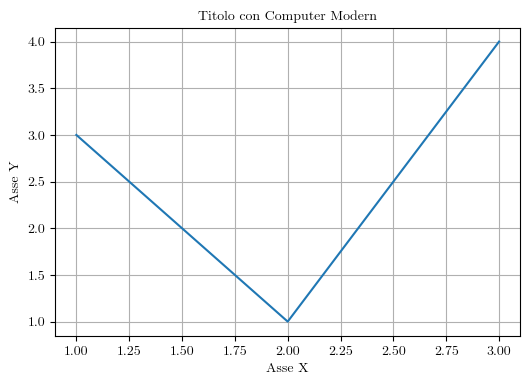

In [5]:
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

font_path = "/content/fonts/cmunrm.ttf"  # Modifica se il file ha un nome diverso
cmu_font = fm.FontProperties(fname=font_path)

plt.figure(figsize=(6, 4))
plt.title("Titolo con Computer Modern", fontproperties=cmu_font)
plt.xlabel("Asse X", fontproperties=cmu_font)
plt.ylabel("Asse Y", fontproperties=cmu_font)
plt.plot([1, 2, 3], [3, 1, 4])
plt.xticks(fontproperties=cmu_font)
plt.yticks(fontproperties=cmu_font)
plt.grid(True)
plt.show()


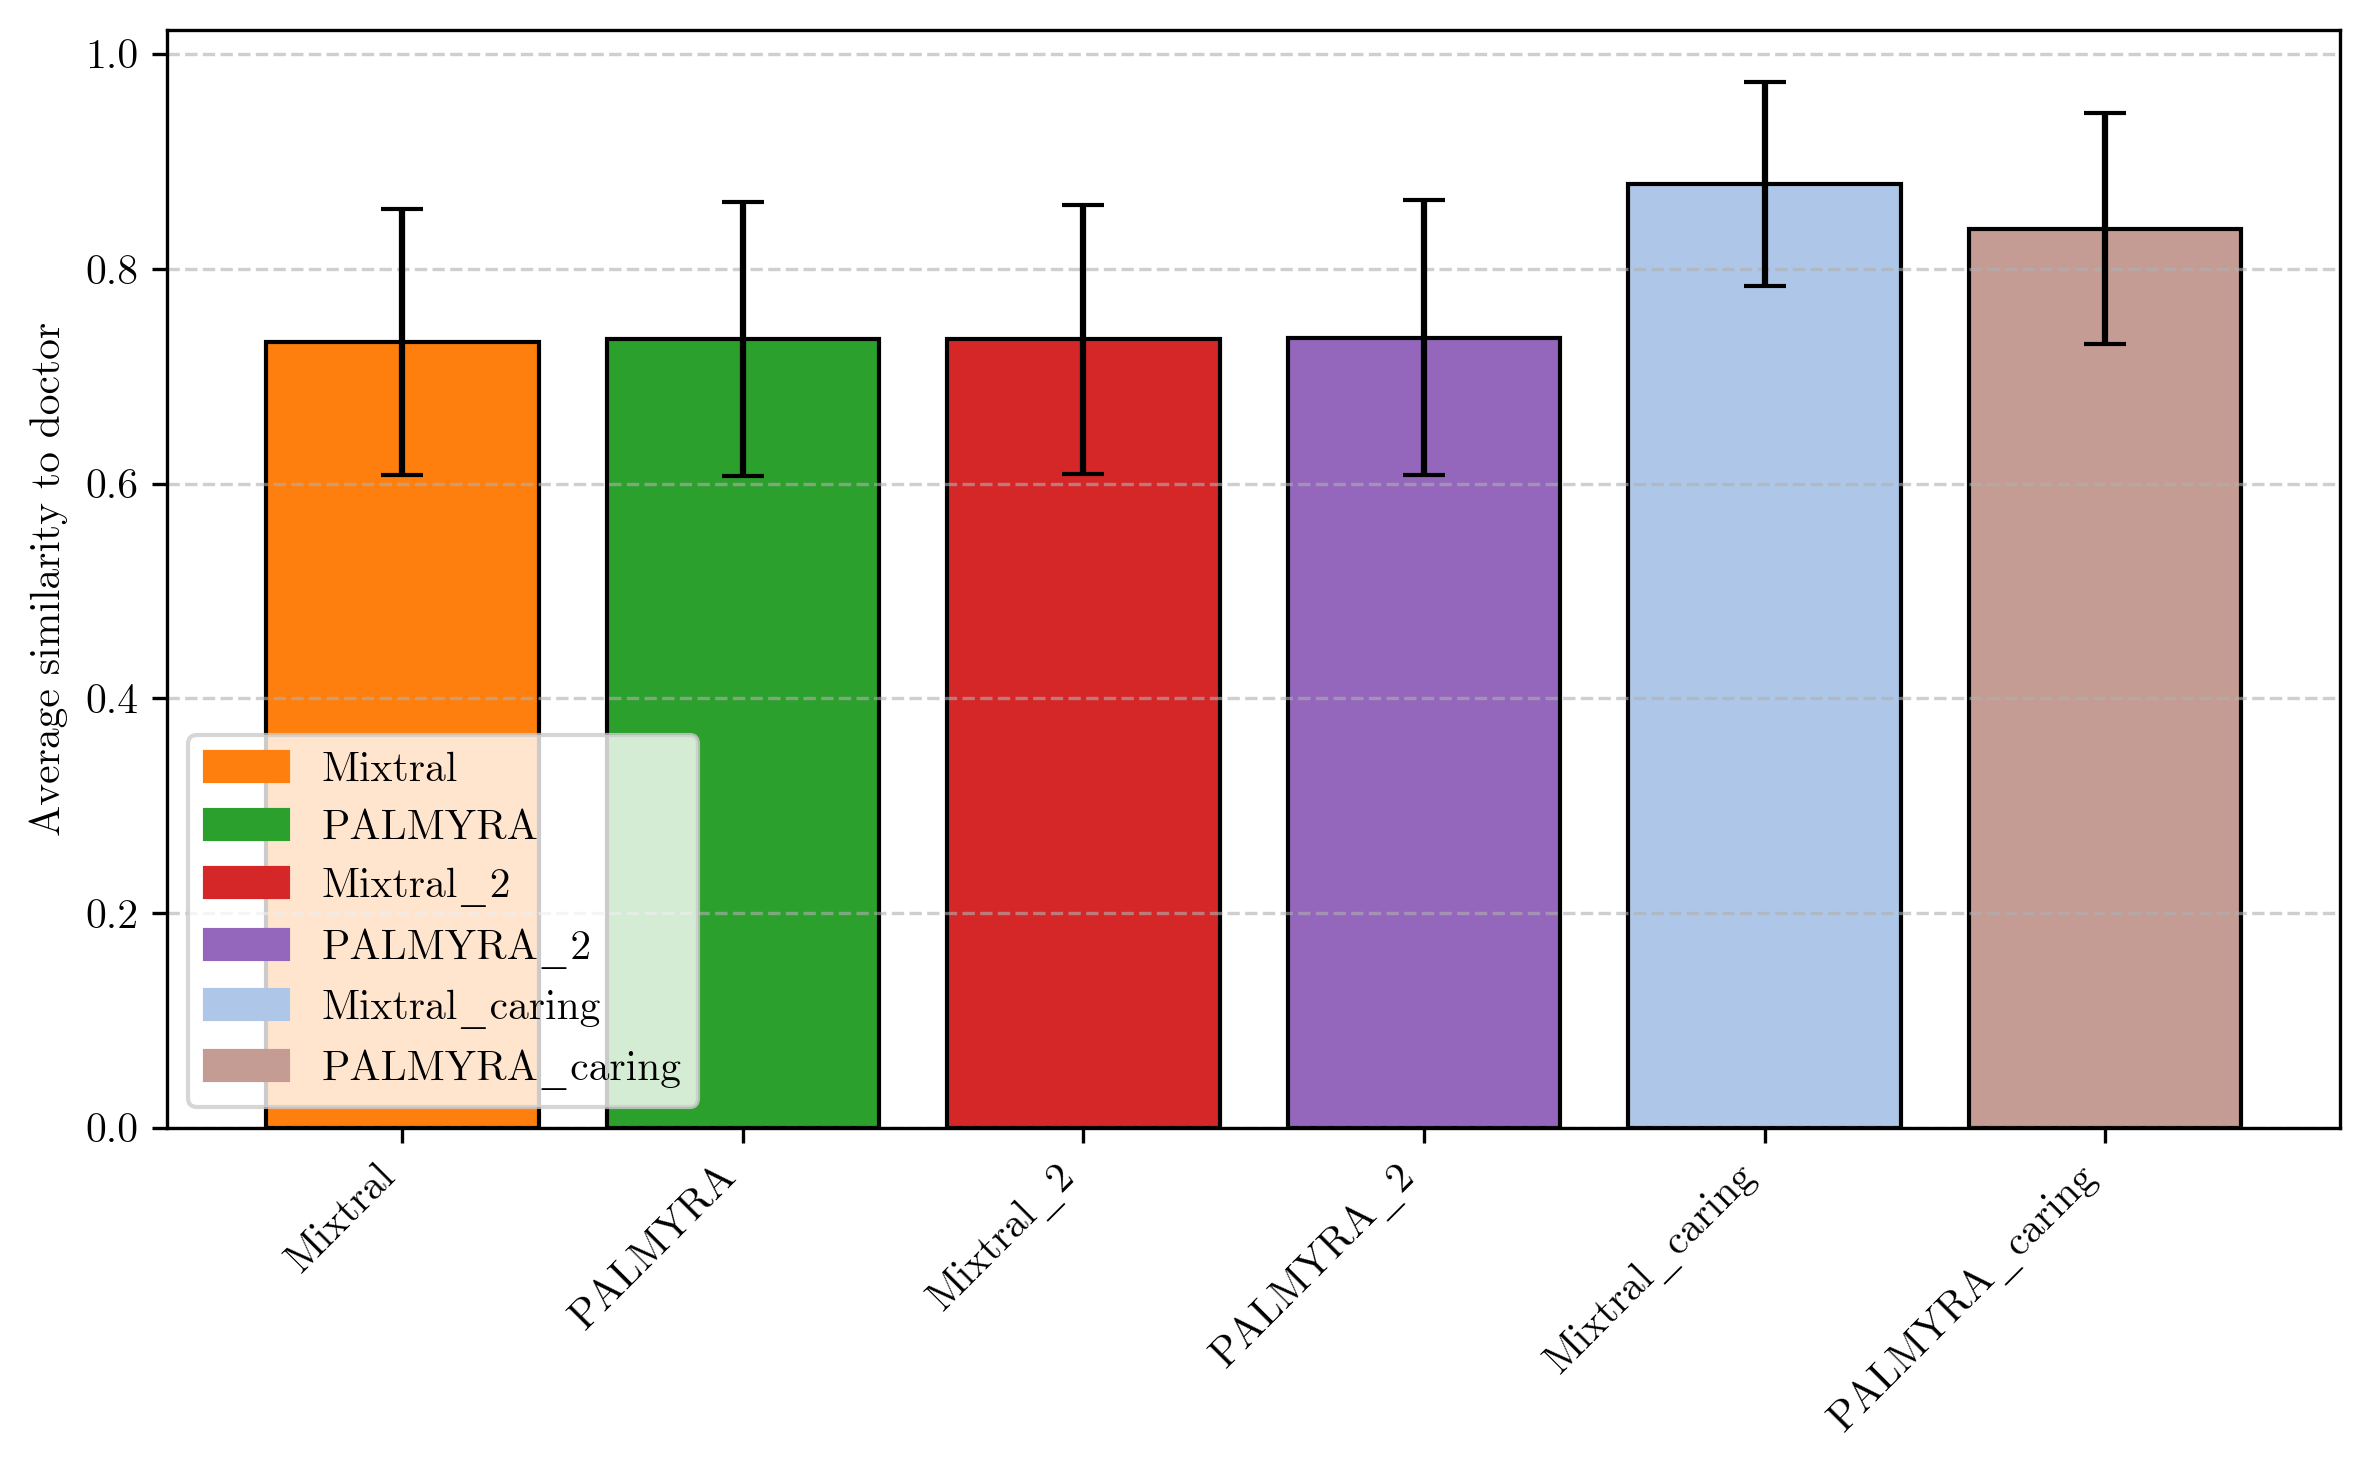

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Etichette aggiornate e colori associati
labels = [
    "Mixtral", "PALMYRA",
    "Mixtral_2", "PALMYRA_2",
    "Mixtral_caring", "PALMYRA_caring"
]

colors = {
    "Doctor": "#1f77b4",
    "Mixtral": "#ff7f0e",
    "Mixtral_2": "#d62728",
    "Mixtral_caring": "#aec7e8",      # light blue
    "PALMYRA": "#2ca02c",
    "PALMYRA_2": "#9467bd",
    "PALMYRA_caring": "#c49c94"       # light brown
}
# Calcolo medie e deviazioni standard
means = [
    df["sim_medico_llm"].mean(),
    df["sim_medico_palmyra"].mean(),
    df["sim_medico_llm_prompt2"].mean(),
    df["sim_medico_palmyra_prompt2"].mean(),
    df["sim_medico_caring_llm"].mean(),
    df["sim_medico_caring_palmyra"].mean()
]

stds = [
    df["sim_medico_llm"].std(),
    df["sim_medico_palmyra"].std(),
    df["sim_medico_llm_prompt2"].std(),
    df["sim_medico_palmyra_prompt2"].std(),
    df["sim_medico_caring_llm"].std(),
    df["sim_medico_caring_palmyra"].std()
]

# Colori per le barre in ordine
bar_colors = [colors[label] for label in labels]

# Grafico a barre
plt.figure(figsize=(8, 5), dpi=300)
plt.bar(labels, means, yerr=stds, capsize=5, color=bar_colors, edgecolor='black')

# Titoli e assi
plt.ylabel("Average similarity to doctor")
plt.title("")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Legenda
legend_patches = [Patch(color=colors[label], label=label) for label in labels]
plt.legend(handles=legend_patches, loc='best', fontsize=7)

# Layout e salvataggio
plt.tight_layout()
plt.savefig("similarity_barplot_with_caring.pdf", format="pdf", dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import seaborn as sns
import pandas as pd

# === PARAMETRI DI STILE ===
title_fontsize = 20
xtick_fontsize = 16
ytick_fontsize = 16
ylabel_fontsize = 16
legend_fontsize = 8

# Etichette aggiornate e colori associati
labels = [
    "Mixtral", "PALMYRA",
    "Mixtral_2", "PALMYRA_2",
    "Mixtral_caring", "PALMYRA_caring"
]

colors = {
    "Doctor": "#1f77b4",
    "Mixtral": "#ff7f0e",
    "Mixtral_2": "#d62728",
    "Mixtral_caring": "#aec7e8",      # light blue
    "PALMYRA": "#2ca02c",
    "PALMYRA_2": "#9467bd",
    "PALMYRA_caring": "#c49c94"       # light brown
}

# Prepara i dati per seaborn
melted = pd.melt(df[[
    "sim_medico_llm", "sim_medico_palmyra",
    "sim_medico_llm_prompt2", "sim_medico_palmyra_prompt2",
    "sim_medico_caring_llm", "sim_medico_caring_palmyra"
]])
melted.columns = ["Model", "Similarity"]

# Plot
plt.figure(figsize=(8, 7), dpi=300)
sns.violinplot(x="Model", y="Similarity", data=melted, palette="pastel")

plt.xticks(ticks=np.arange(6), labels=labels, rotation=45, ha='right', fontsize=xtick_fontsize)
plt.yticks(fontsize=ytick_fontsize)
plt.ylabel("Cosine Similarity", fontsize=ylabel_fontsize)
plt.title("Distribution of Cosine Similarity", fontsize=title_fontsize)

plt.tight_layout()
plt.savefig("similarity_violinplot_with_caring.pdf")
plt.show()


______


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# === PARAMETRI DI STILE ===
title_fontsize = 20
xtick_fontsize = 14
ytick_fontsize = 14
ylabel_fontsize = 16
legend_fontsize = 12

# Etichette leggibili e semanticamente corrette
labels_mapping = {
    "sim_medico_llm": "LLM_Base",
    "sim_medico_palmyra": "LLM_Finetuned",
    "sim_medico_llm_prompt2": "LLM_Base_v2",
    "sim_medico_palmyra_prompt2": "LLM_Finetuned_v2",
    "sim_medico_caring_llm": "LLM_Caring",
    "sim_medico_caring_palmyra": "LLM_Finetuned_Caring"
}

# Colori coerenti (base vs finetuned)
colors = {
    "LLM_Base": "#ff7f0e",
    "LLM_Finetuned": "#2ca02c",
    "LLM_Base_v2": "#d62728",
    "LLM_Finetuned_v2": "#9467bd",
    "LLM_Caring": "#aec7e8",
    "LLM_Finetuned_Caring": "#c49c94"
}

# Prepara i dati
melted = pd.melt(df[list(labels_mapping.keys())])
melted.columns = ["Model", "Similarity"]
melted["Model"] = melted["Model"].map(labels_mapping)

# Ordine desiderato
order = list(labels_mapping.values())

# Plot
plt.figure(figsize=(10, 7), dpi=300)
sns.violinplot(
    x="Model", y="Similarity", data=melted,
    order=order, palette=[colors[label] for label in order]
)

plt.xticks(rotation=45, ha='right', fontsize=xtick_fontsize)
plt.yticks(fontsize=ytick_fontsize)
plt.ylabel("Cosine Similarity", fontsize=ylabel_fontsize)
plt.title("Cosine Similarity: Base vs Finetuned LLMs", fontsize=title_fontsize)

# Layout finale
plt.tight_layout()
plt.savefig("cosine_similarity_violinplot_cleaned.pdf")
plt.show()


In [ ]:
def use_custom_font(font_path: str):
    import matplotlib as mpl
    from matplotlib import font_manager as fm

    # 1. Reset di tutti i parametri rc per evitare override precedenti
    mpl.rcdefaults()

    # 2. Carica il font da file .ttf
    custom_font = fm.FontProperties(fname=font_path)

    # 3. Non impostiamo il font globalmente (evitiamo warning), ma lo ritorniamo
    return custom_font


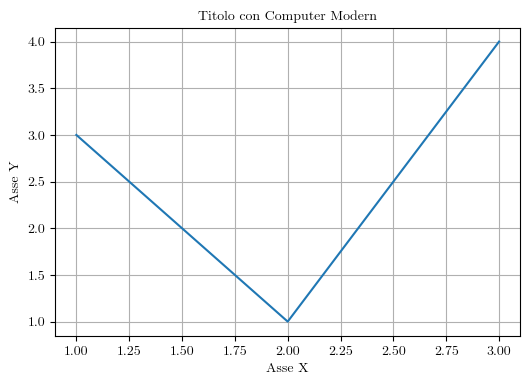

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.title("Titolo con Computer Modern", fontproperties=cmu_font)
plt.xlabel("Asse X", fontproperties=cmu_font)
plt.ylabel("Asse Y", fontproperties=cmu_font)
plt.plot([1, 2, 3], [3, 1, 4])
plt.xticks(fontproperties=cmu_font)
plt.yticks(fontproperties=cmu_font)
plt.grid(True)
plt.show()


In [ ]:
font_path = "/content/fonts/cmunrm.ttf"
cmu_font = use_custom_font(font_path)


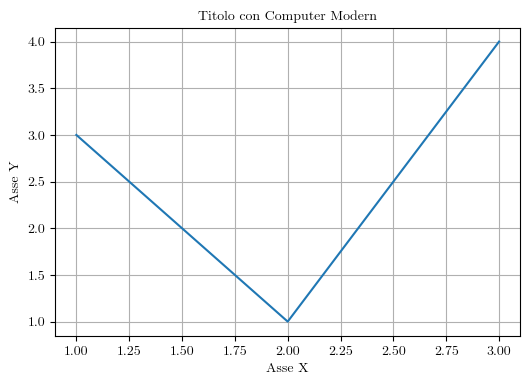

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.title("Titolo con Computer Modern", fontproperties=cmu_font)
plt.xlabel("Asse X", fontproperties=cmu_font)
plt.ylabel("Asse Y", fontproperties=cmu_font)
plt.plot([1, 2, 3], [3, 1, 4])
plt.xticks(fontproperties=cmu_font)
plt.yticks(fontproperties=cmu_font)
plt.grid(True)
plt.show()


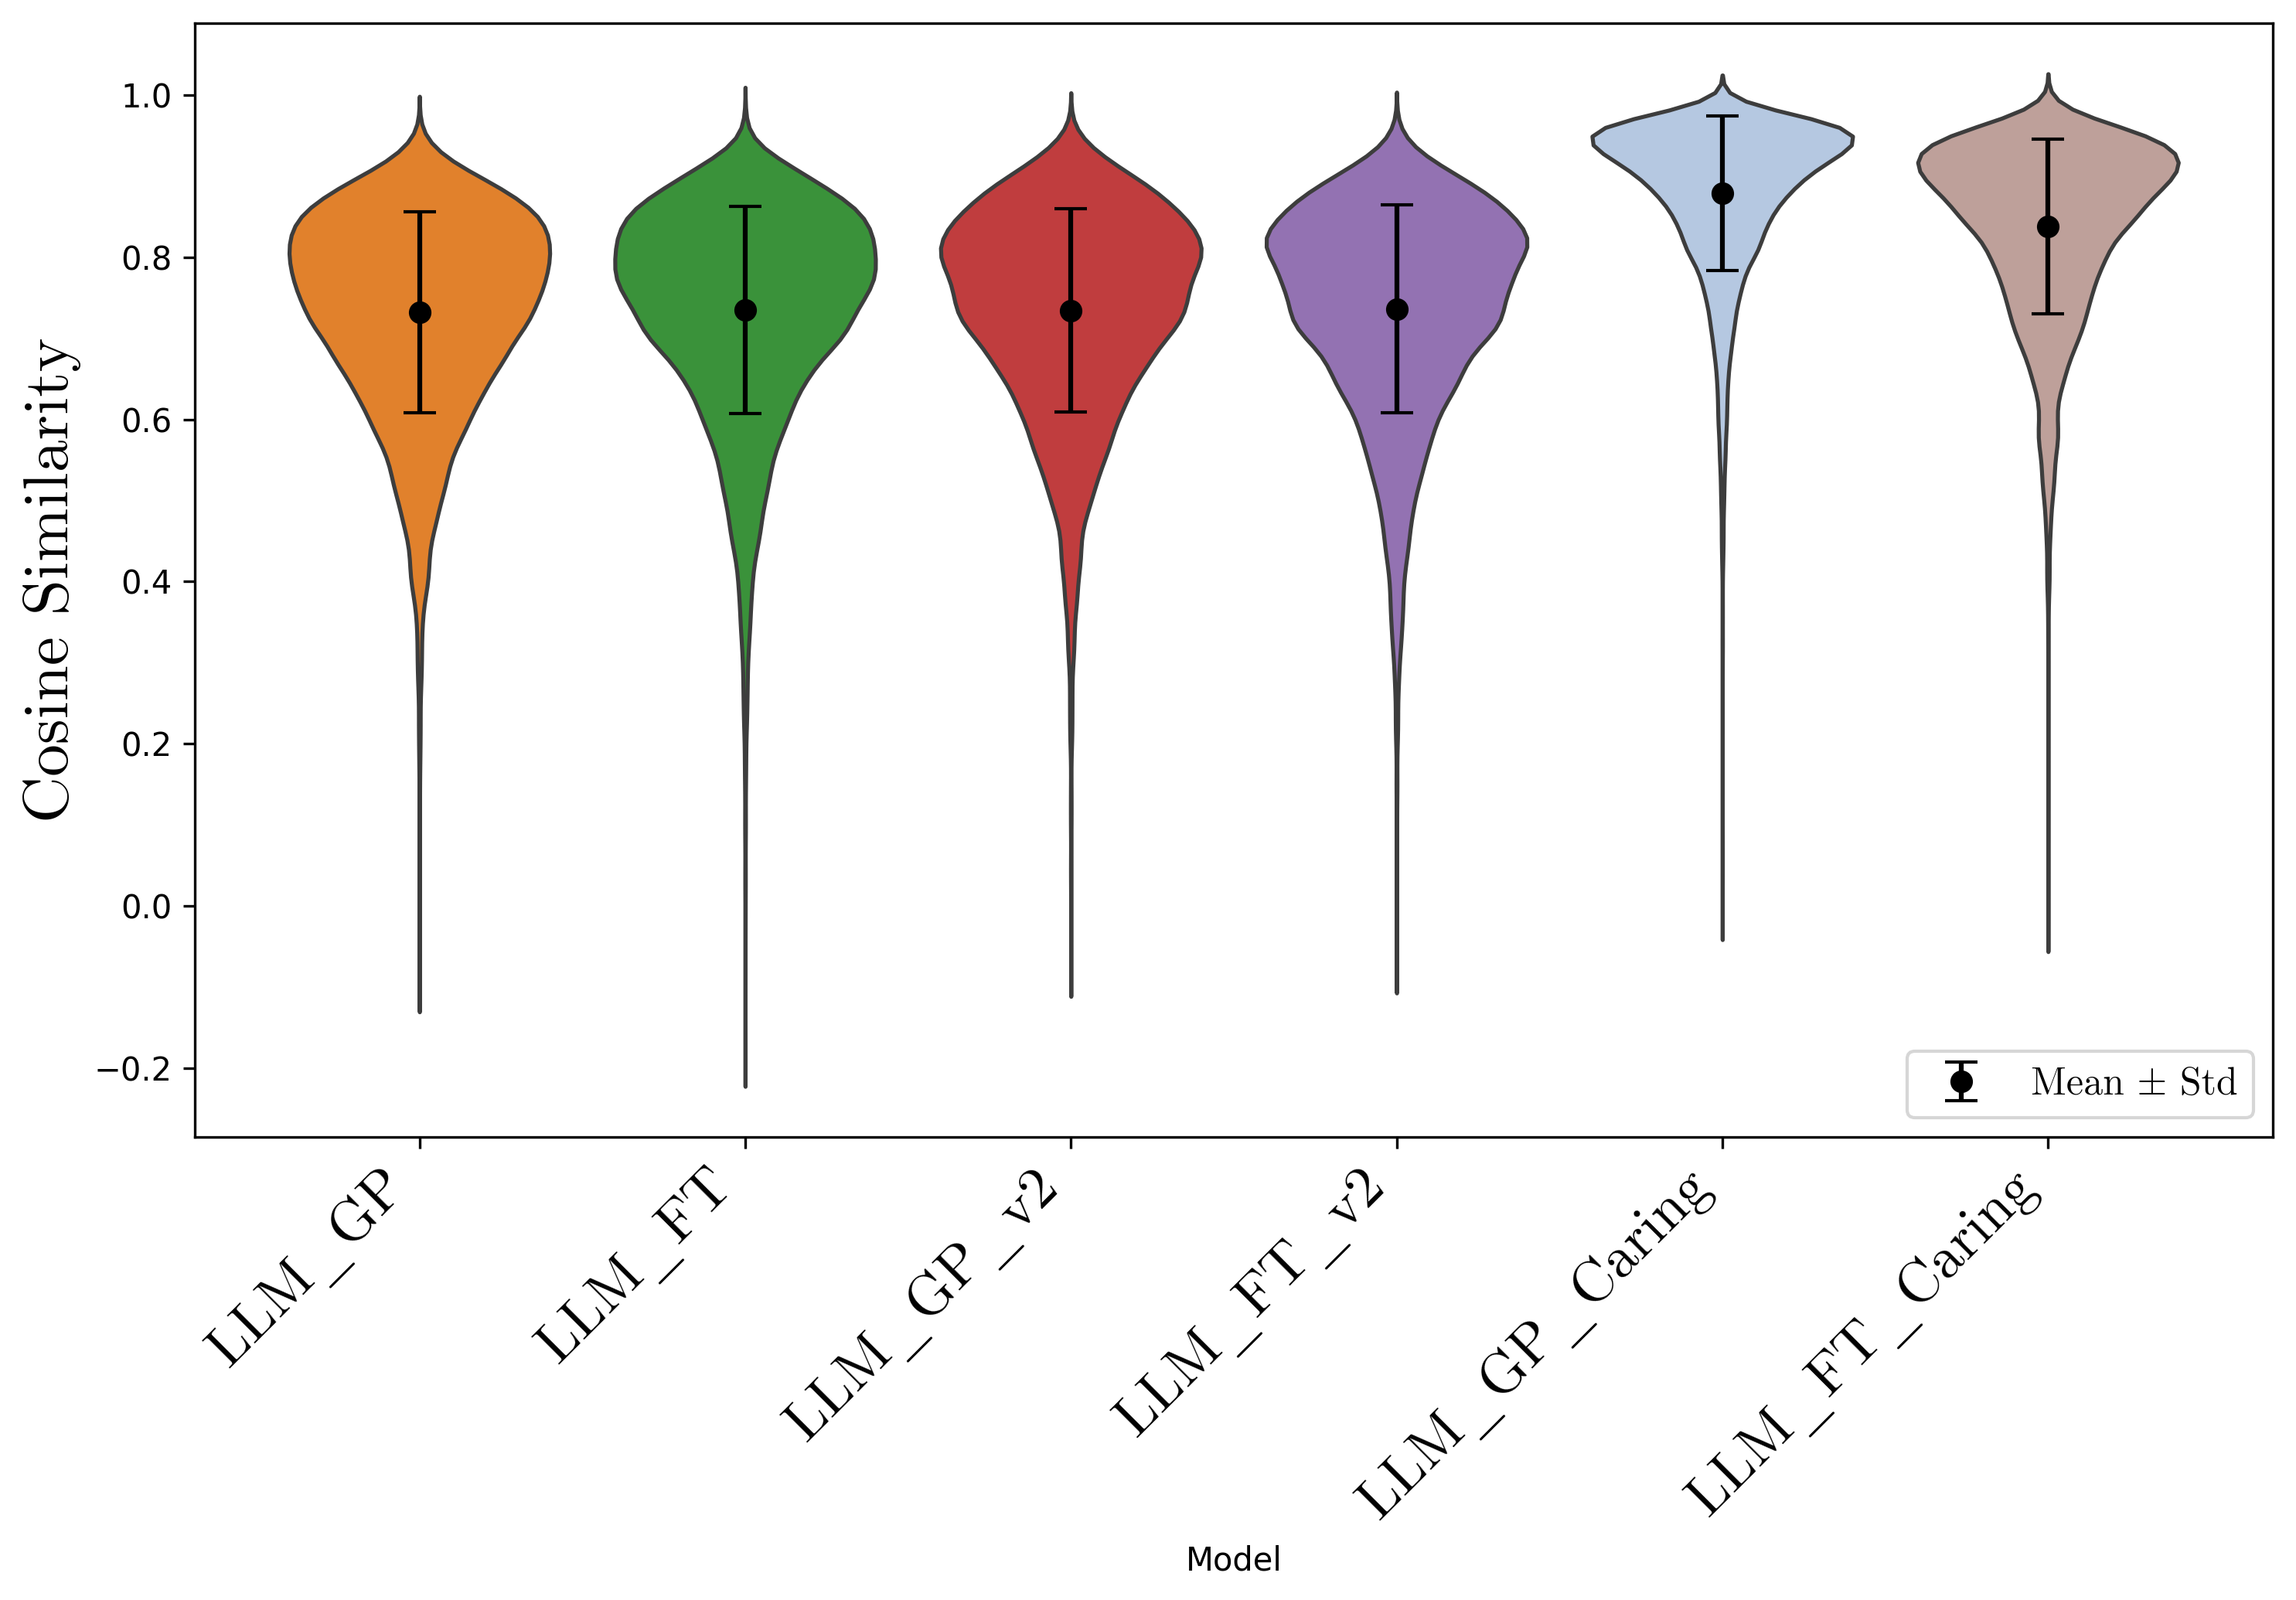

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import font_manager as fm
import matplotlib as mpl

# === Disabilita unicode minus (non sempre basta da solo)
mpl.rcParams['axes.unicode_minus'] = False

# === FUNZIONE PER IL FONT ===
def use_custom_font(font_path: str):
    import matplotlib as mpl
    from matplotlib import font_manager as fm
    mpl.rcdefaults()
    return fm.FontProperties(fname=font_path)

# === CARICA FONT COMPUTER MODERN ===
font_path = "/content/fonts/cmunrm.ttf"
cmu_font = use_custom_font(font_path)
fallback_font = fm.FontProperties(family="DejaVu Sans")  # Per tick numerici negativi

# === Imposta le dimensioni dei font in FontProperties ===
xtick_fontsize = 18
ytick_fontsize = 18
ylabel_fontsize = 20
title_fontsize = 20
legend_fontsize = 12

cmu_font_xtick = cmu_font.copy(); cmu_font_xtick.set_size(xtick_fontsize)
cmu_font_ylabel = cmu_font.copy(); cmu_font_ylabel.set_size(ylabel_fontsize)
cmu_font_title = cmu_font.copy(); cmu_font_title.set_size(title_fontsize)
cmu_font_legend = cmu_font.copy(); cmu_font_legend.set_size(legend_fontsize)

# === Etichette leggibili e semanticamente corrette ===
labels_mapping = {
    "sim_medico_llm": "LLM_GP",
    "sim_medico_palmyra": "LLM_FT",
    "sim_medico_llm_prompt2": "LLM_GP_v2",
    "sim_medico_palmyra_prompt2": "LLM_FT_v2",
    "sim_medico_caring_llm": "LLM_GP_Caring",
    "sim_medico_caring_palmyra": "LLM_FT_Caring"
}

colors = {
    "LLM_GP": "#ff7f0e",
    "LLM_FT": "#2ca02c",
    "LLM_GP_v2": "#d62728",
    "LLM_FT_v2": "#9467bd",
    "LLM_GP_Caring": "#aec7e8",
    "LLM_FT_Caring": "#c49c94"
}

# === Prepara i dati ===
melted = pd.melt(df[list(labels_mapping.keys())])
melted.columns = ["Model", "Similarity"]
melted["Model"] = melted["Model"].map(labels_mapping)

order = [
    "LLM_GP", "LLM_FT",
    "LLM_GP_v2", "LLM_FT_v2",
    "LLM_GP_Caring", "LLM_FT_Caring"
]

# === Plot ===
plt.figure(figsize=(10, 7), dpi=300)

sns.violinplot(
    x="Model",
    y="Similarity",
    data=melted,
    order=order,
    hue="Model",
    palette={label: colors[label] for label in order},
    inner=None,
    legend=False
)

# === Media e deviazione standard ===
group_stats = melted.groupby("Model")["Similarity"].agg(["mean", "std"]).reindex(order)

plt.errorbar(
    x=np.arange(len(order)),
    y=group_stats["mean"],
    yerr=group_stats["std"],
    fmt='o', color='black', capsize=5, markersize=6, label='Mean ± Std'
)

# === Etichette con font ===
plt.xticks(ticks=np.arange(len(order)), labels=order, rotation=45, ha='right',
           fontproperties=cmu_font_xtick)
plt.yticks(fontsize=ytick_fontsize, fontproperties=fallback_font)
plt.ylabel("Cosine Similarity", fontproperties=cmu_font_ylabel)
plt.title("", fontproperties=cmu_font_title)

# === Legenda ===
plt.legend(fontsize=legend_fontsize, loc="lower right", prop=cmu_font_legend)

# === Layout e salvataggio ===
plt.tight_layout()
plt.savefig("cosine_similarity_violinplot_gp_vs_ft.pdf")
plt.show()


In [ ]:
import pandas as pd

# Mapping etichette leggibili
labels_mapping = {
    "sim_medico_llm": "LLM_GP",
    "sim_medico_palmyra": "LLM_FT",
    "sim_medico_llm_prompt2": "LLM_GP_v2",
    "sim_medico_palmyra_prompt2": "LLM_FT_v2",
    "sim_medico_caring_llm": "LLM_GP_Caring",
    "sim_medico_caring_palmyra": "LLM_FT_Caring"
}

# Ordine dei modelli per consistenza
order = [
    "LLM_GP", "LLM_FT",
    "LLM_GP_v2", "LLM_FT_v2",
    "LLM_GP_Caring", "LLM_FT_Caring"
]

# Riorganizza il DataFrame
melted = pd.melt(df[list(labels_mapping.keys())])
melted.columns = ["Model", "Similarity"]
melted["Model"] = melted["Model"].map(labels_mapping)

# Calcolo media e deviazione standard
group_stats = melted.groupby("Model")["Similarity"].agg(["mean", "std"]).reindex(order)

# Arrotonda per leggibilità
group_stats_rounded = group_stats.round(3)

# Stampa tabella
print(group_stats_rounded)

# (Opzionale) salva in CSV
# group_stats_rounded.to_csv("cosine_similarity_stats.csv")


                mean    std
Model                      
LLM_GP         0.732  0.124
LLM_FT         0.735  0.128
LLM_GP_v2      0.734  0.125
LLM_FT_v2      0.736  0.128
LLM_GP_Caring  0.879  0.095
LLM_FT_Caring  0.838  0.108


In [ ]:
import pandas as pd
from scipy.stats import f_oneway, ttest_rel
from statsmodels.stats.multitest import multipletests

# ANOVA Flesch-Kincaid (Medico vs LLM vs PALMYRA)
anova_fk_stat, anova_fk_p = f_oneway(
    df["Answer_medico_FleschKincaid"],
    df["Answer_LLM_FleschKincaid"],
    df["Answer_LLM_PALMYRA_FleschKincaid"]
)

# ANOVA Gunning Fog (Medico vs LLM vs PALMYRA)
anova_gf_stat, anova_gf_p = f_oneway(
    df["Answer_medico_GunningFog"],
    df["Answer_LLM_GunningFog"],
    df["Answer_LLM_PALMYRA_GunningFog"]
)

# T-test Flesch-Kincaid: LLM vs prompt2
t_fk_llm_stat, t_fk_llm_p = ttest_rel(
    df["Answer_LLM_FleschKincaid"],
    df["Answer_LLM_prompt2_FleschKincaid"]
)

# T-test Flesch-Kincaid: PALMYRA vs prompt2
t_fk_palmyra_stat, t_fk_palmyra_p = ttest_rel(
    df["Answer_LLM_PALMYRA_FleschKincaid"],
    df["Answer_LLM_PALMYRA_prompt2_FleschKincaid"]
)

# T-test Gunning Fog: LLM vs prompt2
t_gf_llm_stat, t_gf_llm_p = ttest_rel(
    df["Answer_LLM_GunningFog"],
    df["Answer_LLM_prompt2_GunningFog"]
)

# T-test Gunning Fog: PALMYRA vs prompt2
t_gf_palmyra_stat, t_gf_palmyra_p = ttest_rel(
    df["Answer_LLM_PALMYRA_GunningFog"],
    df["Answer_LLM_PALMYRA_prompt2_GunningFog"]
)

# Nuovi t-test caring
t_fk_caring_llm_stat, t_fk_caring_llm_p = ttest_rel(
    df["Answer_LLM_FleschKincaid"],
    df["Answer_medico_caring_LLM_FleschKincaid"]
)

t_fk_caring_palmyra_stat, t_fk_caring_palmyra_p = ttest_rel(
    df["Answer_LLM_PALMYRA_FleschKincaid"],
    df["Answer_medico_caring_LLM_PALMYRA_FleschKincaid"]
)

t_gf_caring_llm_stat, t_gf_caring_llm_p = ttest_rel(
    df["Answer_LLM_GunningFog"],
    df["Answer_medico_caring_LLM_GunningFog"]
)

t_gf_caring_palmyra_stat, t_gf_caring_palmyra_p = ttest_rel(
    df["Answer_LLM_PALMYRA_GunningFog"],
    df["Answer_medico_caring_LLM_PALMYRA_GunningFog"]
)

# Lista p-value grezzi
raw_pvals = [
    anova_fk_p,
    anova_gf_p,
    t_fk_llm_p,
    t_fk_palmyra_p,
    t_gf_llm_p,
    t_gf_palmyra_p,
    t_fk_caring_llm_p,
    t_fk_caring_palmyra_p,
    t_gf_caring_llm_p,
    t_gf_caring_palmyra_p
]

# Correzione FDR (Benjamini-Hochberg)
rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')

# Risultati in DataFrame
results = pd.DataFrame({
    "Test": [
        "ANOVA Flesch-Kincaid (Medico vs LLM vs PALMYRA)",
        "ANOVA Gunning Fog (Medico vs LLM vs PALMYRA)",
        "T-test Flesch-Kincaid (LLM vs LLM prompt2)",
        "T-test Flesch-Kincaid (PALMYRA vs PALMYRA prompt2)",
        "T-test Gunning Fog (LLM vs LLM prompt2)",
        "T-test Gunning Fog (PALMYRA vs PALMYRA prompt2)",
        "T-test Flesch-Kincaid (LLM vs LLM caring)",
        "T-test Flesch-Kincaid (PALMYRA vs PALMYRA caring)",
        "T-test Gunning Fog (LLM vs LLM caring)",
        "T-test Gunning Fog (PALMYRA vs PALMYRA caring)"
    ],
    "Statistic": [
        anova_fk_stat,
        anova_gf_stat,
        t_fk_llm_stat,
        t_fk_palmyra_stat,
        t_gf_llm_stat,
        t_gf_palmyra_stat,
        t_fk_caring_llm_stat,
        t_fk_caring_palmyra_stat,
        t_gf_caring_llm_stat,
        t_gf_caring_palmyra_stat
    ],
    "p-value": raw_pvals,
    "FDR-corrected p": corrected_pvals,
    "Significativo": rejected
})

# Visualizza i risultati
print(results)


                                                Test    Statistic  \
0    ANOVA Flesch-Kincaid (Medico vs LLM vs PALMYRA)   414.153622   
1       ANOVA Gunning Fog (Medico vs LLM vs PALMYRA)  1004.088403   
2         T-test Flesch-Kincaid (LLM vs LLM prompt2)   134.212062   
3  T-test Flesch-Kincaid (PALMYRA vs PALMYRA prom...   136.257397   
4            T-test Gunning Fog (LLM vs LLM prompt2)    90.081960   
5    T-test Gunning Fog (PALMYRA vs PALMYRA prompt2)   133.061253   
6          T-test Flesch-Kincaid (LLM vs LLM caring)    55.342167   
7  T-test Flesch-Kincaid (PALMYRA vs PALMYRA caring)   154.833161   
8             T-test Gunning Fog (LLM vs LLM caring)    49.401378   
9     T-test Gunning Fog (PALMYRA vs PALMYRA caring)   154.419073   

         p-value  FDR-corrected p  Significativo  
0  4.286480e-179    4.286480e-179           True  
1   0.000000e+00     0.000000e+00           True  
2   0.000000e+00     0.000000e+00           True  
3   0.000000e+00     0.000000e+00   

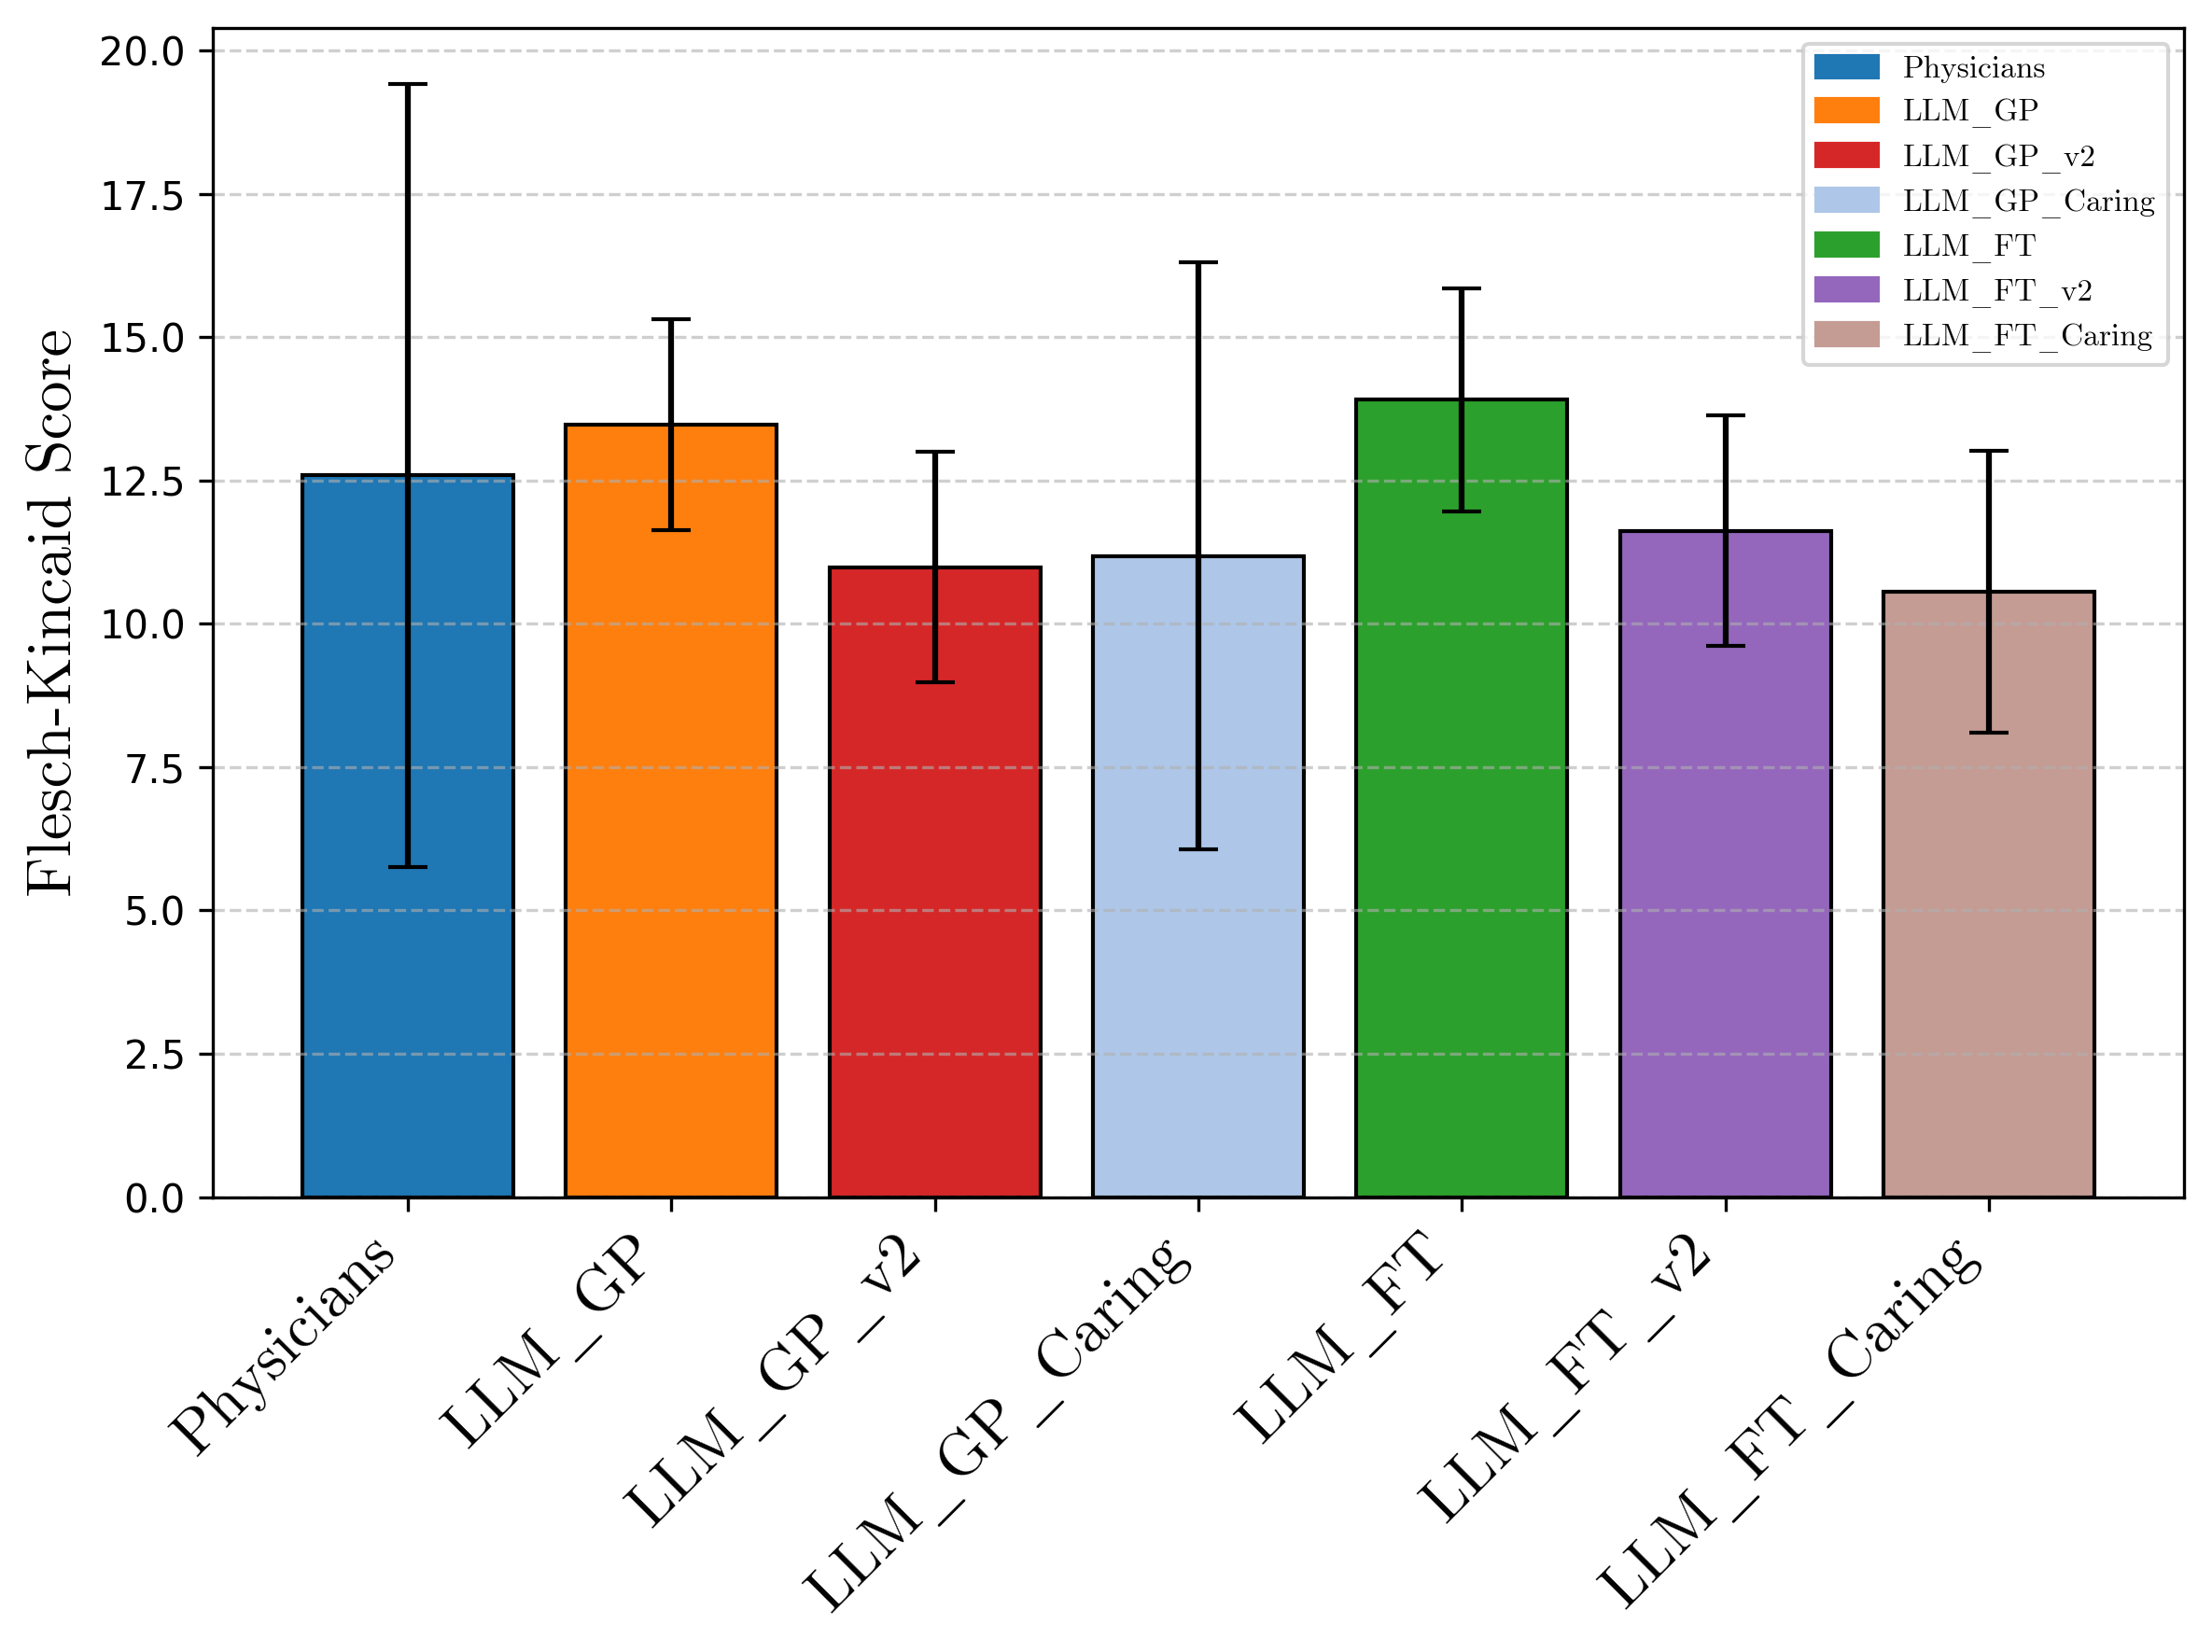

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib import font_manager as fm
import matplotlib as mpl

# === Disabilita il simbolo unicode minus ===
mpl.rcParams['axes.unicode_minus'] = False

# === FUNZIONE PER IL FONT ===
def use_custom_font(font_path: str):
    import matplotlib as mpl
    from matplotlib import font_manager as fm
    mpl.rcdefaults()
    return fm.FontProperties(fname=font_path)

# === CARICA FONT COMPUTER MODERN ===
font_path = "/content/fonts/cmunrm.ttf"
cmu_font = use_custom_font(font_path)
fallback_font = fm.FontProperties(family="DejaVu Sans")  # Per tick numerici

# === Imposta dimensioni dei font personalizzati ===
title_fontsize = 20
xtick_fontsize = 16
ytick_fontsize = 16
ylabel_fontsize = 16
legend_fontsize = 8

cmu_font_title = cmu_font.copy(); cmu_font_title.set_size(title_fontsize)
cmu_font_ylabel = cmu_font.copy(); cmu_font_ylabel.set_size(ylabel_fontsize)
cmu_font_xtick = cmu_font.copy(); cmu_font_xtick.set_size(xtick_fontsize)
cmu_font_legend = cmu_font.copy(); cmu_font_legend.set_size(legend_fontsize)

# === COLORI COERENTI (GP vs FT) ===
colors = {
    "Physicians": "#1f77b4",
    "LLM_GP": "#ff7f0e",
    "LLM_GP_v2": "#d62728",
    "LLM_GP_Caring": "#aec7e8",
    "LLM_FT": "#2ca02c",
    "LLM_FT_v2": "#9467bd",
    "LLM_FT_Caring": "#c49c94"
}

# === ETICHETTE COERENTI ===
labels = [
    "Physicians",
    "LLM_GP", "LLM_GP_v2", "LLM_GP_Caring",
    "LLM_FT", "LLM_FT_v2", "LLM_FT_Caring"
]
label_names = labels

# === MEDIE E DEVIAZIONI STANDARD ===
means = [
    df["Answer_medico_FleschKincaid"].mean(),
    df["Answer_LLM_FleschKincaid"].mean(),
    df["Answer_LLM_prompt2_FleschKincaid"].mean(),
    df["Answer_medico_caring_LLM_FleschKincaid"].mean(),
    df["Answer_LLM_PALMYRA_FleschKincaid"].mean(),
    df["Answer_LLM_PALMYRA_prompt2_FleschKincaid"].mean(),
    df["Answer_medico_caring_LLM_PALMYRA_FleschKincaid"].mean()
]
stds = [
    df["Answer_medico_FleschKincaid"].std(),
    df["Answer_LLM_FleschKincaid"].std(),
    df["Answer_LLM_prompt2_FleschKincaid"].std(),
    df["Answer_medico_caring_LLM_FleschKincaid"].std(),
    df["Answer_LLM_PALMYRA_FleschKincaid"].std(),
    df["Answer_LLM_PALMYRA_prompt2_FleschKincaid"].std(),
    df["Answer_medico_caring_LLM_PALMYRA_FleschKincaid"].std()
]

bar_colors = [colors[label] for label in labels]

# === PLOT ===
plt.figure(figsize=(8, 6), dpi=300)
plt.bar(label_names, means, yerr=stds, capsize=5, color=bar_colors, edgecolor='black')

plt.ylabel("Flesch-Kincaid Score", fontproperties=cmu_font_ylabel)
plt.title("", fontproperties=cmu_font_title)
plt.xticks(rotation=45, ha='right', fontproperties=cmu_font_xtick)
plt.yticks(fontsize=ytick_fontsize, fontproperties=fallback_font)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# === LEGENDA ===
legend_elements = [Patch(color=colors[lab], label=lab) for lab in labels]
plt.legend(handles=legend_elements, loc="best", prop=cmu_font_legend)

# === Layout finale ===
plt.tight_layout()
plt.savefig("flesch_kincaid_barplot_gp_ft.pdf")
plt.show()


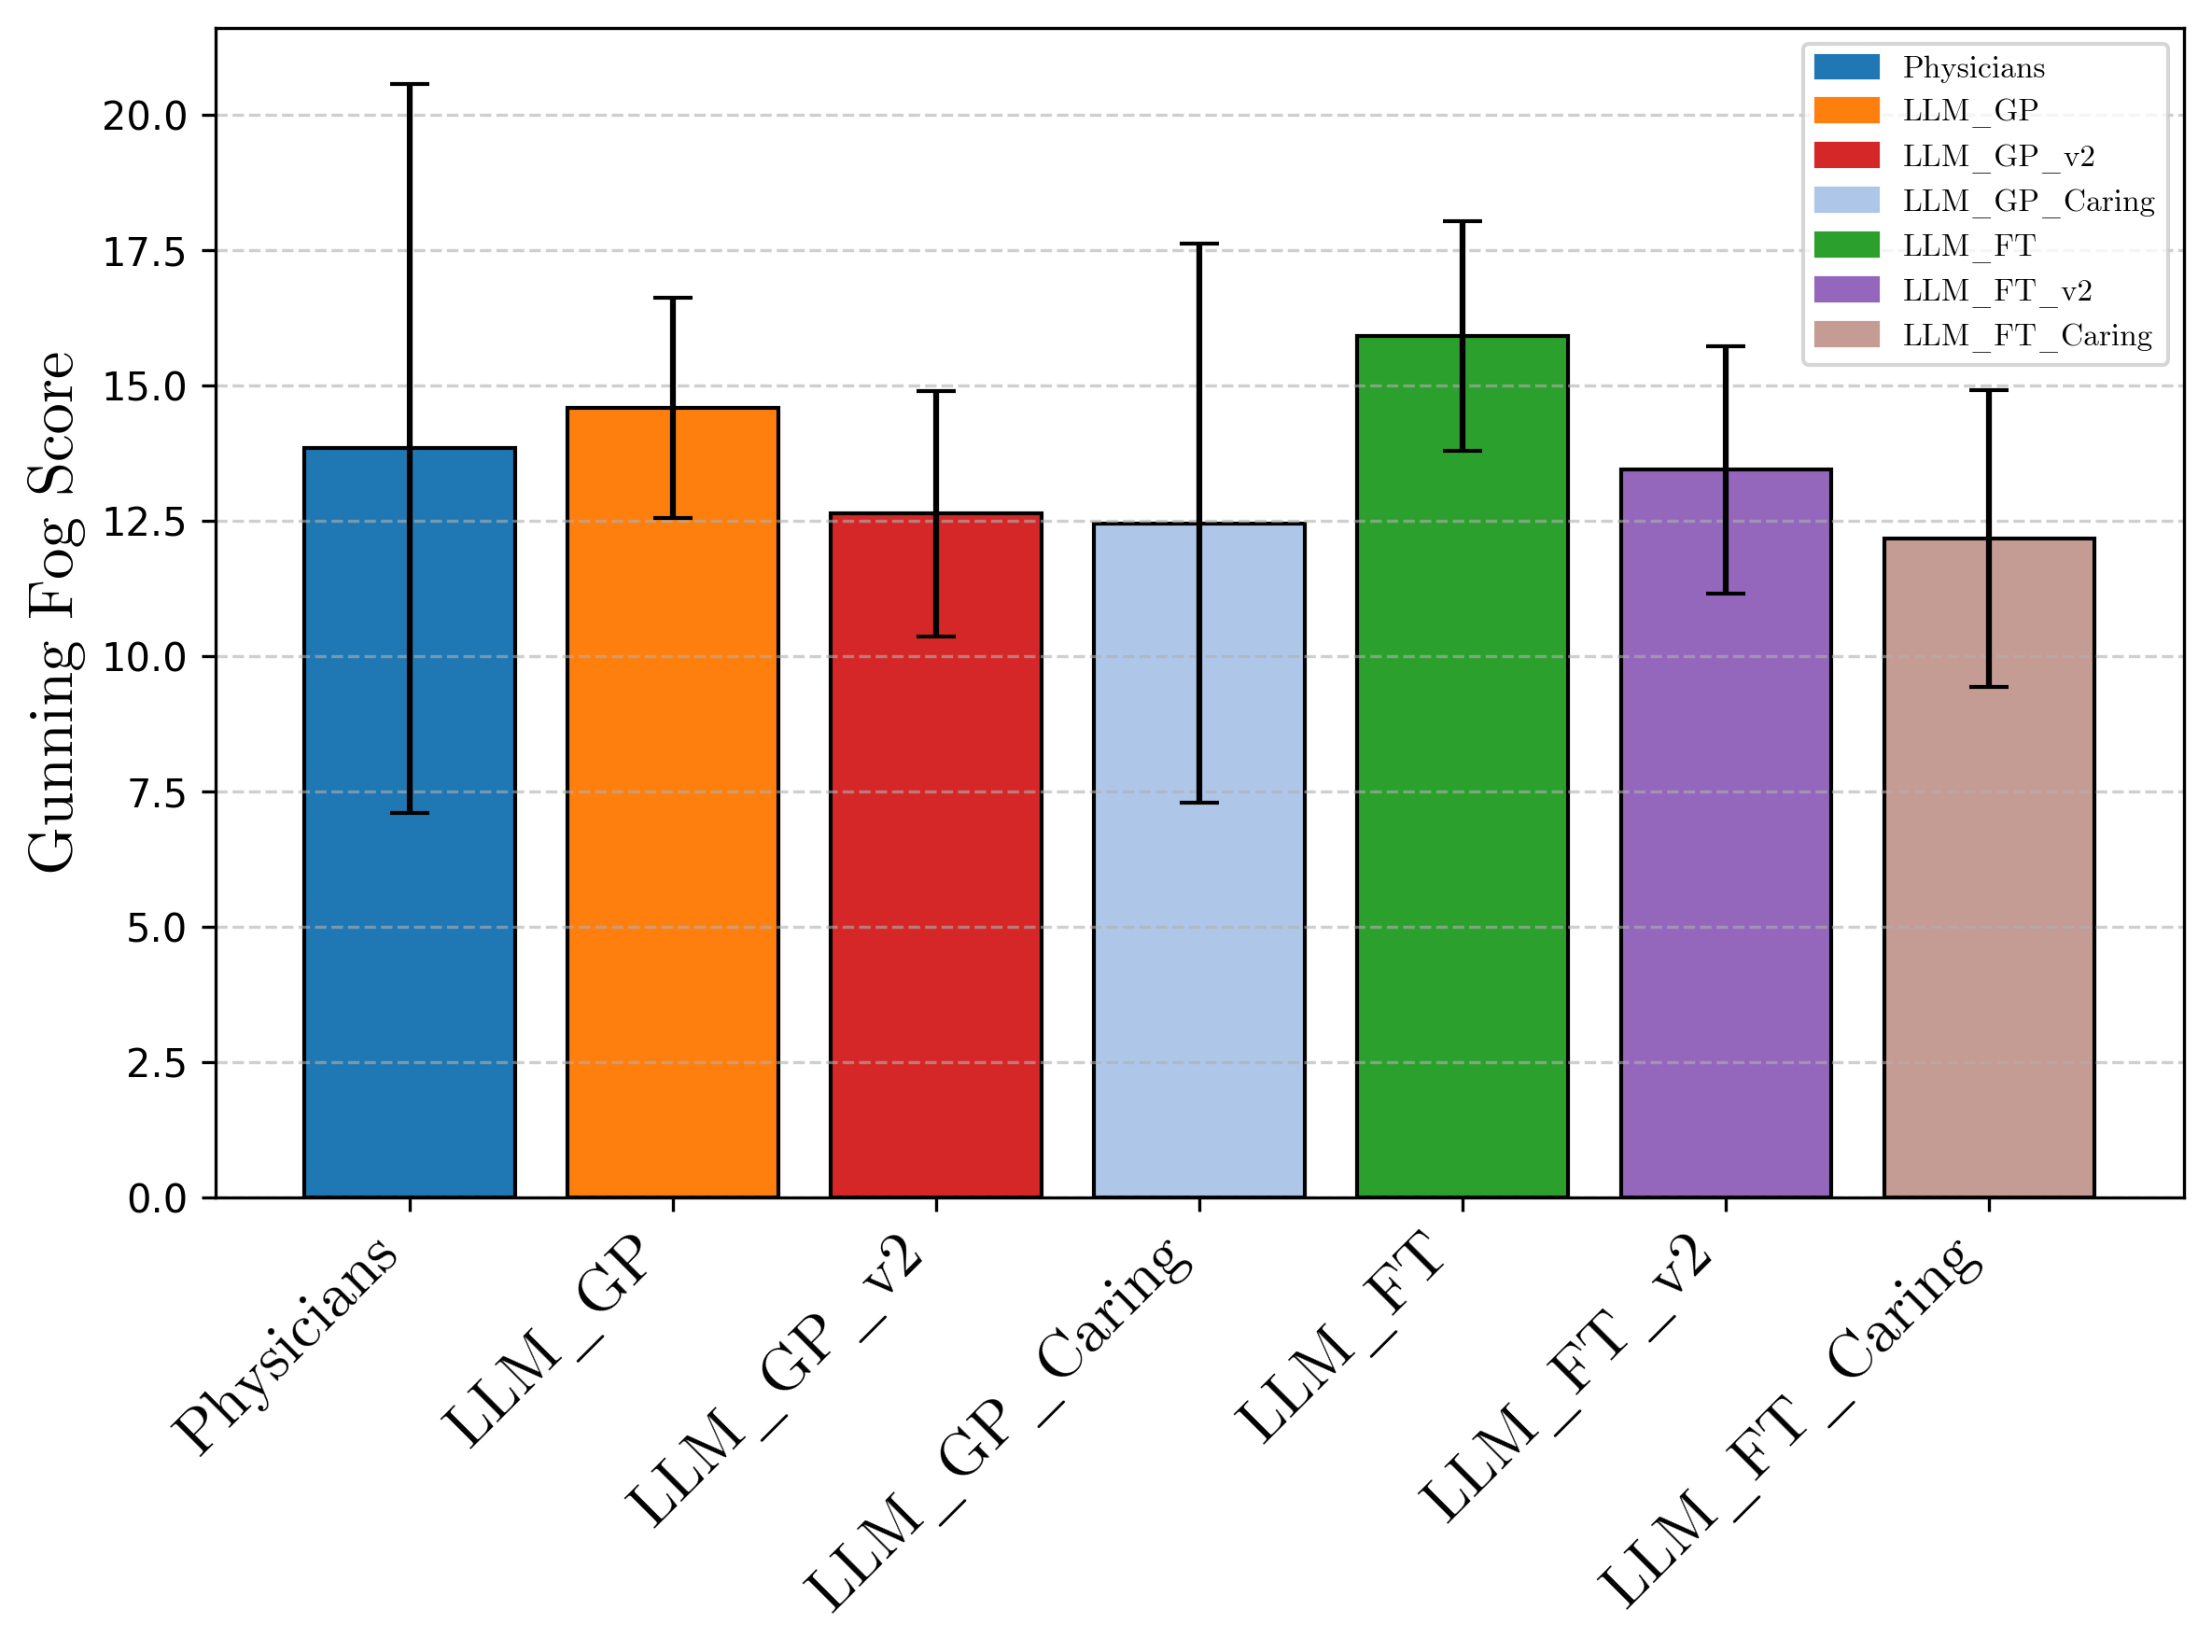

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib import font_manager as fm
import matplotlib as mpl

# === Disabilita simbolo minus unicode
mpl.rcParams['axes.unicode_minus'] = False

# === FUNZIONE PER IL FONT ===
def use_custom_font(font_path: str):
    import matplotlib as mpl
    from matplotlib import font_manager as fm
    mpl.rcdefaults()
    return fm.FontProperties(fname=font_path)

# === CARICA FONT COMPUTER MODERN ===
font_path = "/content/fonts/cmunrm.ttf"
cmu_font = use_custom_font(font_path)
fallback_font = fm.FontProperties(family="DejaVu Sans")  # Per assi numerici

# === Imposta dimensioni dei font ===
title_fontsize = 20
xtick_fontsize = 16
ytick_fontsize = 16
ylabel_fontsize = 16
legend_fontsize = 8

cmu_font_title = cmu_font.copy(); cmu_font_title.set_size(title_fontsize)
cmu_font_ylabel = cmu_font.copy(); cmu_font_ylabel.set_size(ylabel_fontsize)
cmu_font_xtick = cmu_font.copy(); cmu_font_xtick.set_size(xtick_fontsize)
cmu_font_legend = cmu_font.copy(); cmu_font_legend.set_size(legend_fontsize)

# === COLORI COERENTI (GP vs FT) ===
colors = {
    "Physicians": "#1f77b4",
    "LLM_GP": "#ff7f0e",
    "LLM_GP_v2": "#d62728",
    "LLM_GP_Caring": "#aec7e8",      # light blue
    "LLM_FT": "#2ca02c",
    "LLM_FT_v2": "#9467bd",
    "LLM_FT_Caring": "#c49c94"       # light brown
}

# === ETICHETTE COERENTI ===
labels = [
    "Physicians",
    "LLM_GP", "LLM_GP_v2", "LLM_GP_Caring",
    "LLM_FT", "LLM_FT_v2", "LLM_FT_Caring"
]
label_names = labels

# === MEDIE E DEVIAZIONI STANDARD ===
means = [
    df["Answer_medico_GunningFog"].mean(),
    df["Answer_LLM_GunningFog"].mean(),
    df["Answer_LLM_prompt2_GunningFog"].mean(),
    df["Answer_medico_caring_LLM_GunningFog"].mean(),
    df["Answer_LLM_PALMYRA_GunningFog"].mean(),
    df["Answer_LLM_PALMYRA_prompt2_GunningFog"].mean(),
    df["Answer_medico_caring_LLM_PALMYRA_GunningFog"].mean()
]
stds = [
    df["Answer_medico_GunningFog"].std(),
    df["Answer_LLM_GunningFog"].std(),
    df["Answer_LLM_prompt2_GunningFog"].std(),
    df["Answer_medico_caring_LLM_GunningFog"].std(),
    df["Answer_LLM_PALMYRA_GunningFog"].std(),
    df["Answer_LLM_PALMYRA_prompt2_GunningFog"].std(),
    df["Answer_medico_caring_LLM_PALMYRA_GunningFog"].std()
]
bar_colors = [colors[label] for label in labels]

# === PLOT ===
plt.figure(figsize=(8, 6), dpi=300)
plt.bar(label_names, means, yerr=stds, capsize=5, color=bar_colors, edgecolor='black')

plt.ylabel("Gunning Fog Score", fontproperties=cmu_font_ylabel)
plt.title("", fontproperties=cmu_font_title)
plt.xticks(rotation=45, ha='right', fontproperties=cmu_font_xtick)
plt.yticks(fontsize=ytick_fontsize, fontproperties=fallback_font)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# === LEGENDA ===
legend_elements = [Patch(color=colors[lab], label=lab) for lab in labels]
plt.legend(handles=legend_elements, loc="best", prop=cmu_font_legend)

plt.tight_layout()
plt.savefig("gunning_fog_barplot_gp_ft.pdf")
plt.show()


In [ ]:
import pandas as pd

# Nomi dei sistemi
label_names = [
    "Physicians",
    "Mixtral", "Mixtral Prompt2", "Mixtral Caring",
    "PALMYRA", "PALMYRA Prompt2", "PALMYRA Caring"
]

# === ESTRAZIONE FLESCH-KINCAID ===
flesch_means = [
    df["Answer_medico_FleschKincaid"].mean(),
    df["Answer_LLM_FleschKincaid"].mean(),
    df["Answer_LLM_prompt2_FleschKincaid"].mean(),
    df["Answer_medico_caring_LLM_FleschKincaid"].mean(),
    df["Answer_LLM_PALMYRA_FleschKincaid"].mean(),
    df["Answer_LLM_PALMYRA_prompt2_FleschKincaid"].mean(),
    df["Answer_medico_caring_LLM_PALMYRA_FleschKincaid"].mean()
]
flesch_stds = [
    df["Answer_medico_FleschKincaid"].std(),
    df["Answer_LLM_FleschKincaid"].std(),
    df["Answer_LLM_prompt2_FleschKincaid"].std(),
    df["Answer_medico_caring_LLM_FleschKincaid"].std(),
    df["Answer_LLM_PALMYRA_FleschKincaid"].std(),
    df["Answer_LLM_PALMYRA_prompt2_FleschKincaid"].std(),
    df["Answer_medico_caring_LLM_PALMYRA_FleschKincaid"].std()
]

# === ESTRAZIONE GUNNING FOG ===
fog_means = [
    df["Answer_medico_GunningFog"].mean(),
    df["Answer_LLM_GunningFog"].mean(),
    df["Answer_LLM_prompt2_GunningFog"].mean(),
    df["Answer_medico_caring_LLM_GunningFog"].mean(),
    df["Answer_LLM_PALMYRA_GunningFog"].mean(),
    df["Answer_LLM_PALMYRA_prompt2_GunningFog"].mean(),
    df["Answer_medico_caring_LLM_PALMYRA_GunningFog"].mean()
]
fog_stds = [
    df["Answer_medico_GunningFog"].std(),
    df["Answer_LLM_GunningFog"].std(),
    df["Answer_LLM_prompt2_GunningFog"].std(),
    df["Answer_medico_caring_LLM_GunningFog"].std(),
    df["Answer_LLM_PALMYRA_GunningFog"].std(),
    df["Answer_LLM_PALMYRA_prompt2_GunningFog"].std(),
    df["Answer_medico_caring_LLM_PALMYRA_GunningFog"].std()
]

# === CREAZIONE TABELLA ===
results_df = pd.DataFrame({
    "System": label_names,
    "Flesch-Kincaid Mean": flesch_means,
    "Flesch-Kincaid Std": flesch_stds,
    "Gunning Fog Mean": fog_means,
    "Gunning Fog Std": fog_stds
})

## Creazione della tabella
results_df = pd.DataFrame({
    "System": label_names,
    "Flesch-Kincaid Mean": flesch_means,
    "Flesch-Kincaid Std": flesch_stds,
    "Gunning Fog Mean": fog_means,
    "Gunning Fog Std": fog_stds
})

# Stampa tabella
print(results_df.round(2))  # Arrotonda a 2 cifre decimali per leggibilità

# (Opzionale) salva in CSV
# results_df.to_csv("readability_scores.csv", index=False)

            System  Flesch-Kincaid Mean  Flesch-Kincaid Std  Gunning Fog Mean  \
0       Physicians                12.59                6.83             13.84   
1          Mixtral                13.48                1.84             14.58   
2  Mixtral Prompt2                10.99                2.01             12.63   
3   Mixtral Caring                11.18                5.12             12.45   
4          PALMYRA                13.91                1.94             15.91   
5  PALMYRA Prompt2                11.62                2.01             13.44   
6   PALMYRA Caring                10.56                2.46             12.16   

   Gunning Fog Std  
0             6.73  
1             2.03  
2             2.27  
3             5.16  
4             2.12  
5             2.29  
6             2.74  


Lunghezza

In [ ]:
import pandas as pd
from scipy.stats import f_oneway, ttest_rel
from statsmodels.stats.multitest import multipletests

# ANOVA: lunghezza tra medico, LLM, PALMYRA
anova_len_stat, anova_len_p = f_oneway(
    df["Length_Answer_medico"],
    df["Length_Answer_LLM"],
    df["Length_Answer_LLM_PALMYRA"]
)

# T-test: LLM vs LLM prompt2
t_len_llm_stat, t_len_llm_p = ttest_rel(
    df["Length_Answer_LLM"],
    df["Length_Answer_LLM_prompt2"]
)

# T-test: PALMYRA vs PALMYRA prompt2
t_len_palmyra_stat, t_len_palmyra_p = ttest_rel(
    df["Length_Answer_LLM_PALMYRA"],
    df["Length_Answer_LLM_PALMYRA_prompt2"]
)

# T-test: LLM vs LLM caring
t_len_caring_llm_stat, t_len_caring_llm_p = ttest_rel(
    df["Length_Answer_LLM"],
    df["Length_Answer_medico_caring_LLM"]
)

# T-test: PALMYRA vs PALMYRA caring
t_len_caring_palmyra_stat, t_len_caring_palmyra_p = ttest_rel(
    df["Length_Answer_LLM_PALMYRA"],
    df["Length_Answer_medico_caring_LLM_PALMYRA"]
)

# Lista p-value grezzi
raw_pvals = [
    anova_len_p,
    t_len_llm_p,
    t_len_palmyra_p,
    t_len_caring_llm_p,
    t_len_caring_palmyra_p
]

# Correzione FDR
rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')

# Costruzione DataFrame dei risultati
results = pd.DataFrame({
    "Test": [
        "ANOVA Lunghezza (Medico vs LLM vs PALMYRA)",
        "T-test Lunghezza (LLM vs LLM prompt2)",
        "T-test Lunghezza (PALMYRA vs PALMYRA prompt2)",
        "T-test Lunghezza (LLM vs LLM caring)",
        "T-test Lunghezza (PALMYRA vs PALMYRA caring)"
    ],
    "Statistic": [
        anova_len_stat,
        t_len_llm_stat,
        t_len_palmyra_stat,
        t_len_caring_llm_stat,
        t_len_caring_palmyra_stat
    ],
    "p-value": [f"{p:.2e}" for p in raw_pvals],
    "FDR-corrected p": [f"{p:.2e}" for p in corrected_pvals],
    "Significativo": rejected
})

# Stampa dei risultati
print(results)


                                            Test    Statistic   p-value  \
0     ANOVA Lunghezza (Medico vs LLM vs PALMYRA)  1216.124080  0.00e+00   
1          T-test Lunghezza (LLM vs LLM prompt2)   183.056559  0.00e+00   
2  T-test Lunghezza (PALMYRA vs PALMYRA prompt2)    94.591274  0.00e+00   
3           T-test Lunghezza (LLM vs LLM caring)    56.407240  0.00e+00   
4   T-test Lunghezza (PALMYRA vs PALMYRA caring)    64.378791  0.00e+00   

  FDR-corrected p  Significativo  
0        0.00e+00           True  
1        0.00e+00           True  
2        0.00e+00           True  
3        0.00e+00           True  
4        0.00e+00           True  


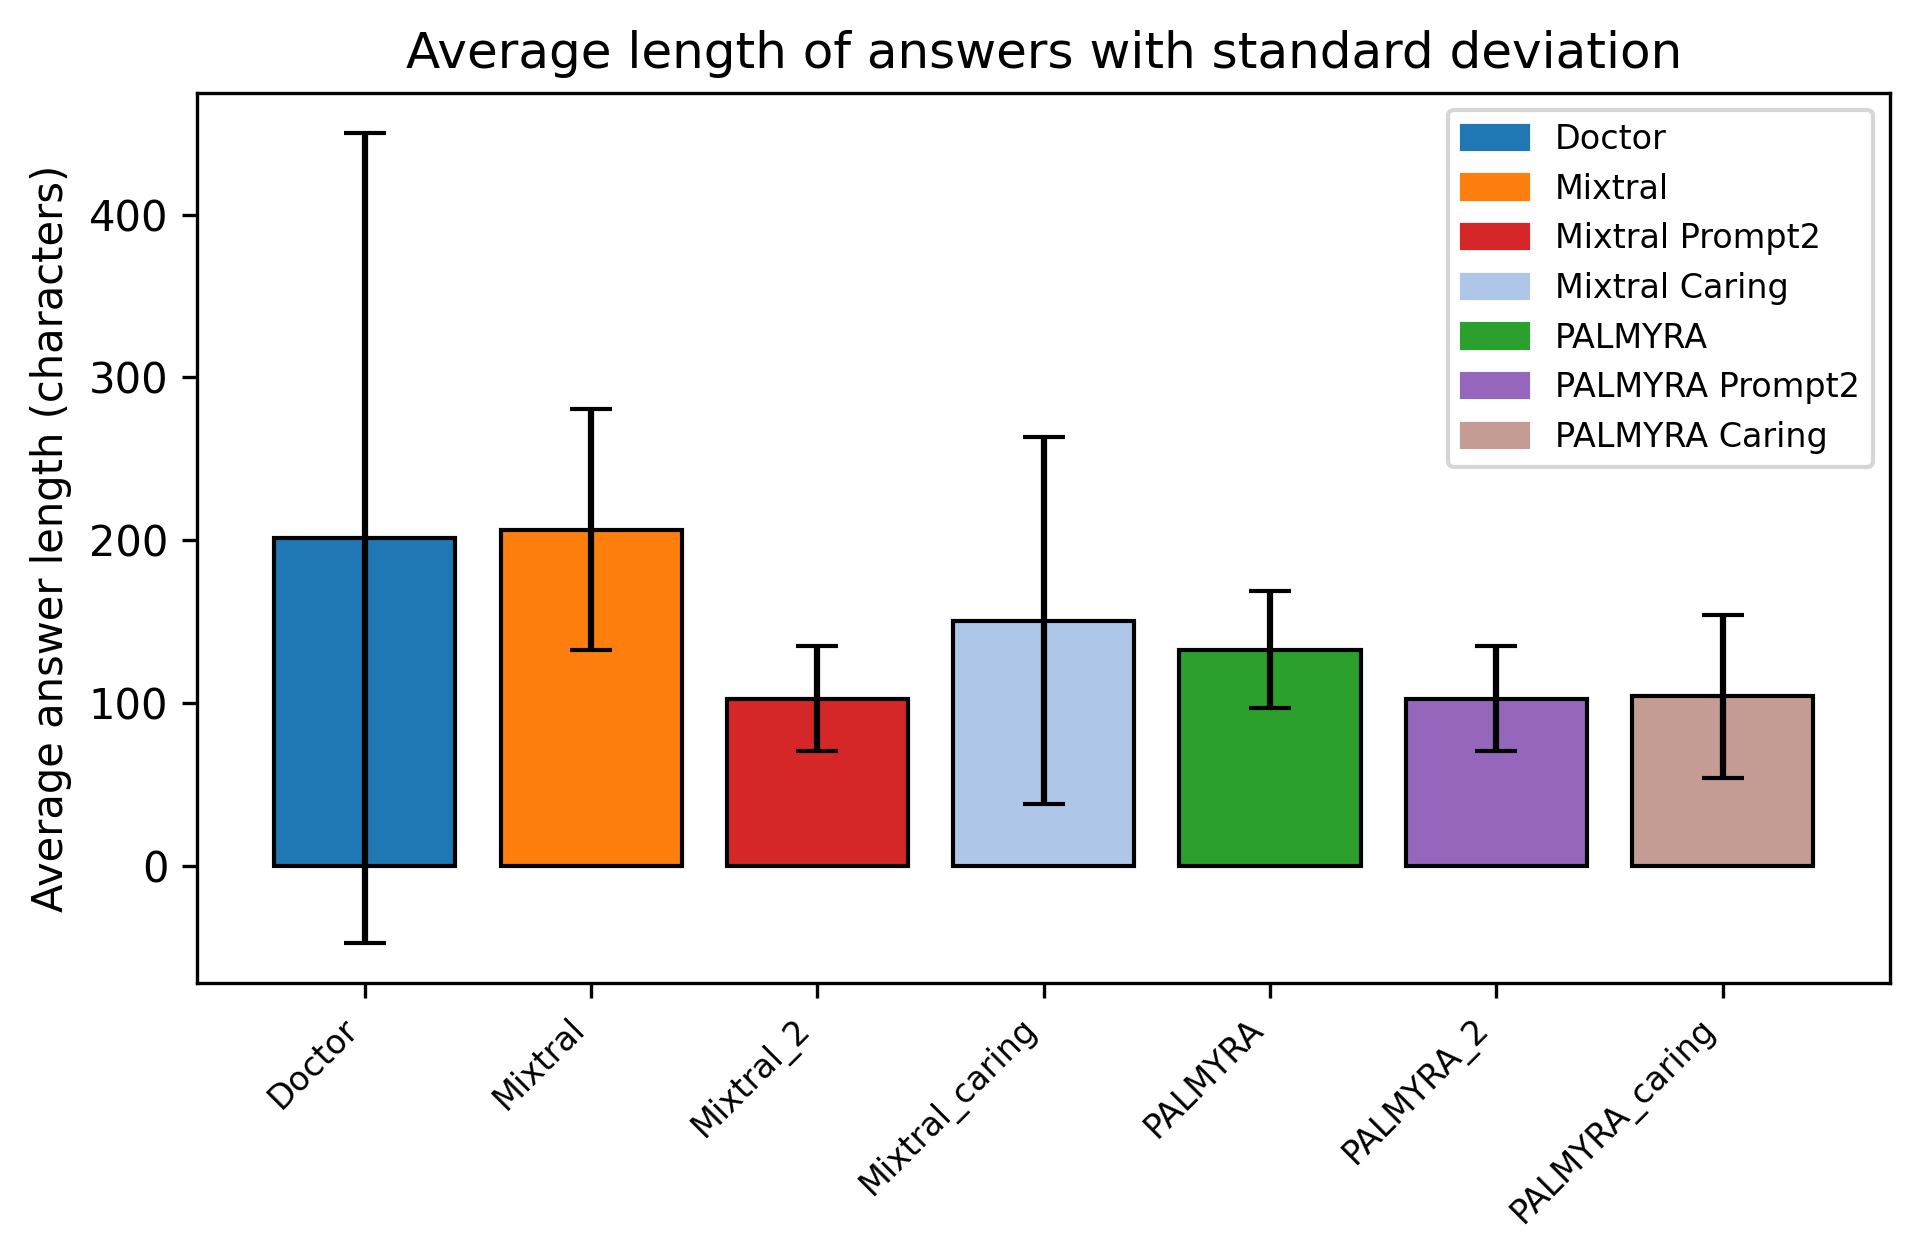

Plot saved as: answer_length_barplot_with_caring.pdf


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Dizionario delle colonne con etichette leggibili
columns = {
    "Length_Answer_medico": "Doctor",
    "Length_Answer_LLM": "Mixtral",
    "Length_Answer_LLM_prompt2": "Mixtral_2",
    "Length_Answer_medico_caring_LLM": "Mixtral_caring",
    "Length_Answer_LLM_PALMYRA": "PALMYRA",
    "Length_Answer_LLM_PALMYRA_prompt2": "PALMYRA_2",
    "Length_Answer_medico_caring_LLM_PALMYRA": "PALMYRA_caring"
}

# Colori personalizzati
colors = {
    "Doctor": "#1f77b4",              # blue
    "Mixtral": "#ff7f0e",             # orange
    "Mixtral_2": "#d62728",           # red
    "Mixtral_caring": "#aec7e8",      # light blue
    "PALMYRA": "#2ca02c",             # green
    "PALMYRA_2": "#9467bd",           # purple
    "PALMYRA_caring": "#c49c94"       # light brown
}

# Font size per etichette asse x
x_label_size = 8

# Calcolo delle medie e deviazioni standard
means = [df[col].mean() for col in columns]
std_devs = [df[col].std() for col in columns]
labels = list(columns.values())
bar_colors = [colors[label] for label in labels]

# Creazione del bar plot
plt.figure(figsize=(6.5, 4.3), dpi=300)
plt.bar(labels, means, yerr=std_devs, capsize=5, color=bar_colors, edgecolor='black')

# Etichette assi e titolo
plt.xticks(rotation=45, ha='right', fontsize=x_label_size)
plt.ylabel("Average answer length (characters)")
plt.title("Average length of answers with standard deviation")
plt.tight_layout()

# Legenda
legend_patches = [Patch(color=colors[label], label=label.replace("_2", " Prompt2").replace("_caring", " Caring")) for label in labels]
plt.legend(handles=legend_patches, loc='upper right', fontsize=8)

# Salva e mostra il grafico
pdf_path = "answer_length_barplot_with_caring.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300)
plt.show()

print(f"Plot saved as: {pdf_path}")


Sentiment_ negativo postivio neutro etc



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16407 entries, 0 to 16406
Data columns (total 59 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Unnamed: 0                                      16407 non-null  int64  
 1   context                                         16407 non-null  object 
 2   question                                        16407 non-null  object 
 3   Answer_medico                                   16407 non-null  object 
 4   Answer_LLM                                      16407 non-null  object 
 5   Answer_LLM_PALMYRA                              16407 non-null  object 
 6   Sentiment_medico                                16407 non-null  object 
 7   Sentiment_LLM                                   16407 non-null  object 
 8   Sentiment_LLM_PALMYRA                           16407 non-null  object 
 9   Answer_medico_concepts                 

In [ ]:
from statsmodels.stats.multitest import multipletests
import pandas as pd
from scipy.stats import chi2_contingency

sentiment_labels = sorted([
    "Very Negative", "Negative", "Neutral", "Positive", "Very Positive"
])

# Costruzione della tabella di contingenza
contingency = pd.DataFrame({
    "Doctor": df["Sentiment_medico"].value_counts().reindex(sentiment_labels, fill_value=0),
    "Mixtral": df["Sentiment_LLM"].value_counts().reindex(sentiment_labels, fill_value=0),
    "PALMYRA": df["Sentiment_LLM_PALMYRA"].value_counts().reindex(sentiment_labels, fill_value=0),
    "Mixtral_2": df["Sentiment_LLM_prompt2"].value_counts().reindex(sentiment_labels, fill_value=0),
    "PALMYRA_2": df["Sentiment_LLM_PALMYRA_prompt2"].value_counts().reindex(sentiment_labels, fill_value=0),
    "Caring_Mixtral": df["Sentiment_CARING_LLM"].value_counts().reindex(sentiment_labels, fill_value=0),
    "Caring_PALMYRA": df["Sentiment_CARING_PALMYRA"].value_counts().reindex(sentiment_labels, fill_value=0)
})

# Nuove coppie da confrontare
comparisons = ["Mixtral", "PALMYRA", "Mixtral_2", "PALMYRA_2", "Caring_Mixtral", "Caring_PALMYRA"]
raw_pvals = []
stats = []
dofs = []

for model in comparisons:
    temp_df = pd.DataFrame({
        "Doctor": contingency["Doctor"],
        model: contingency[model]
    })
    stat, p, dof, _ = chi2_contingency(temp_df)
    raw_pvals.append(p)
    stats.append(stat)
    dofs.append(dof)

# Correzione FDR
rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')

# Risultati
fdr_results = pd.DataFrame({
    "Comparison": [f"Doctor vs {m}" for m in comparisons],
    "Chi2 Statistic": stats,
    "Degrees of Freedom": dofs,
    "Raw p-value": raw_pvals,
    "FDR-corrected p-value": corrected_pvals,
    "Significant": rejected
})



,Comparison,Chi2 Statistic,Degrees of Freedom,Raw p-value,FDR-corrected p-value,Significant
0,Doctor vs Mixtral,624.748776,4,6.816955e-134,1.363391e-133,True
1,Doctor vs PALMYRA,2243.657027,4,0.000000e+00,0.000000e+00,True
2,Doctor vs Mixtral_2,57.328803,4,1.055466e-11,1.055466e-11,True
3,Doctor vs PALMYRA_2,338.023965,4,6.753178e-72,9.004238e-72,True


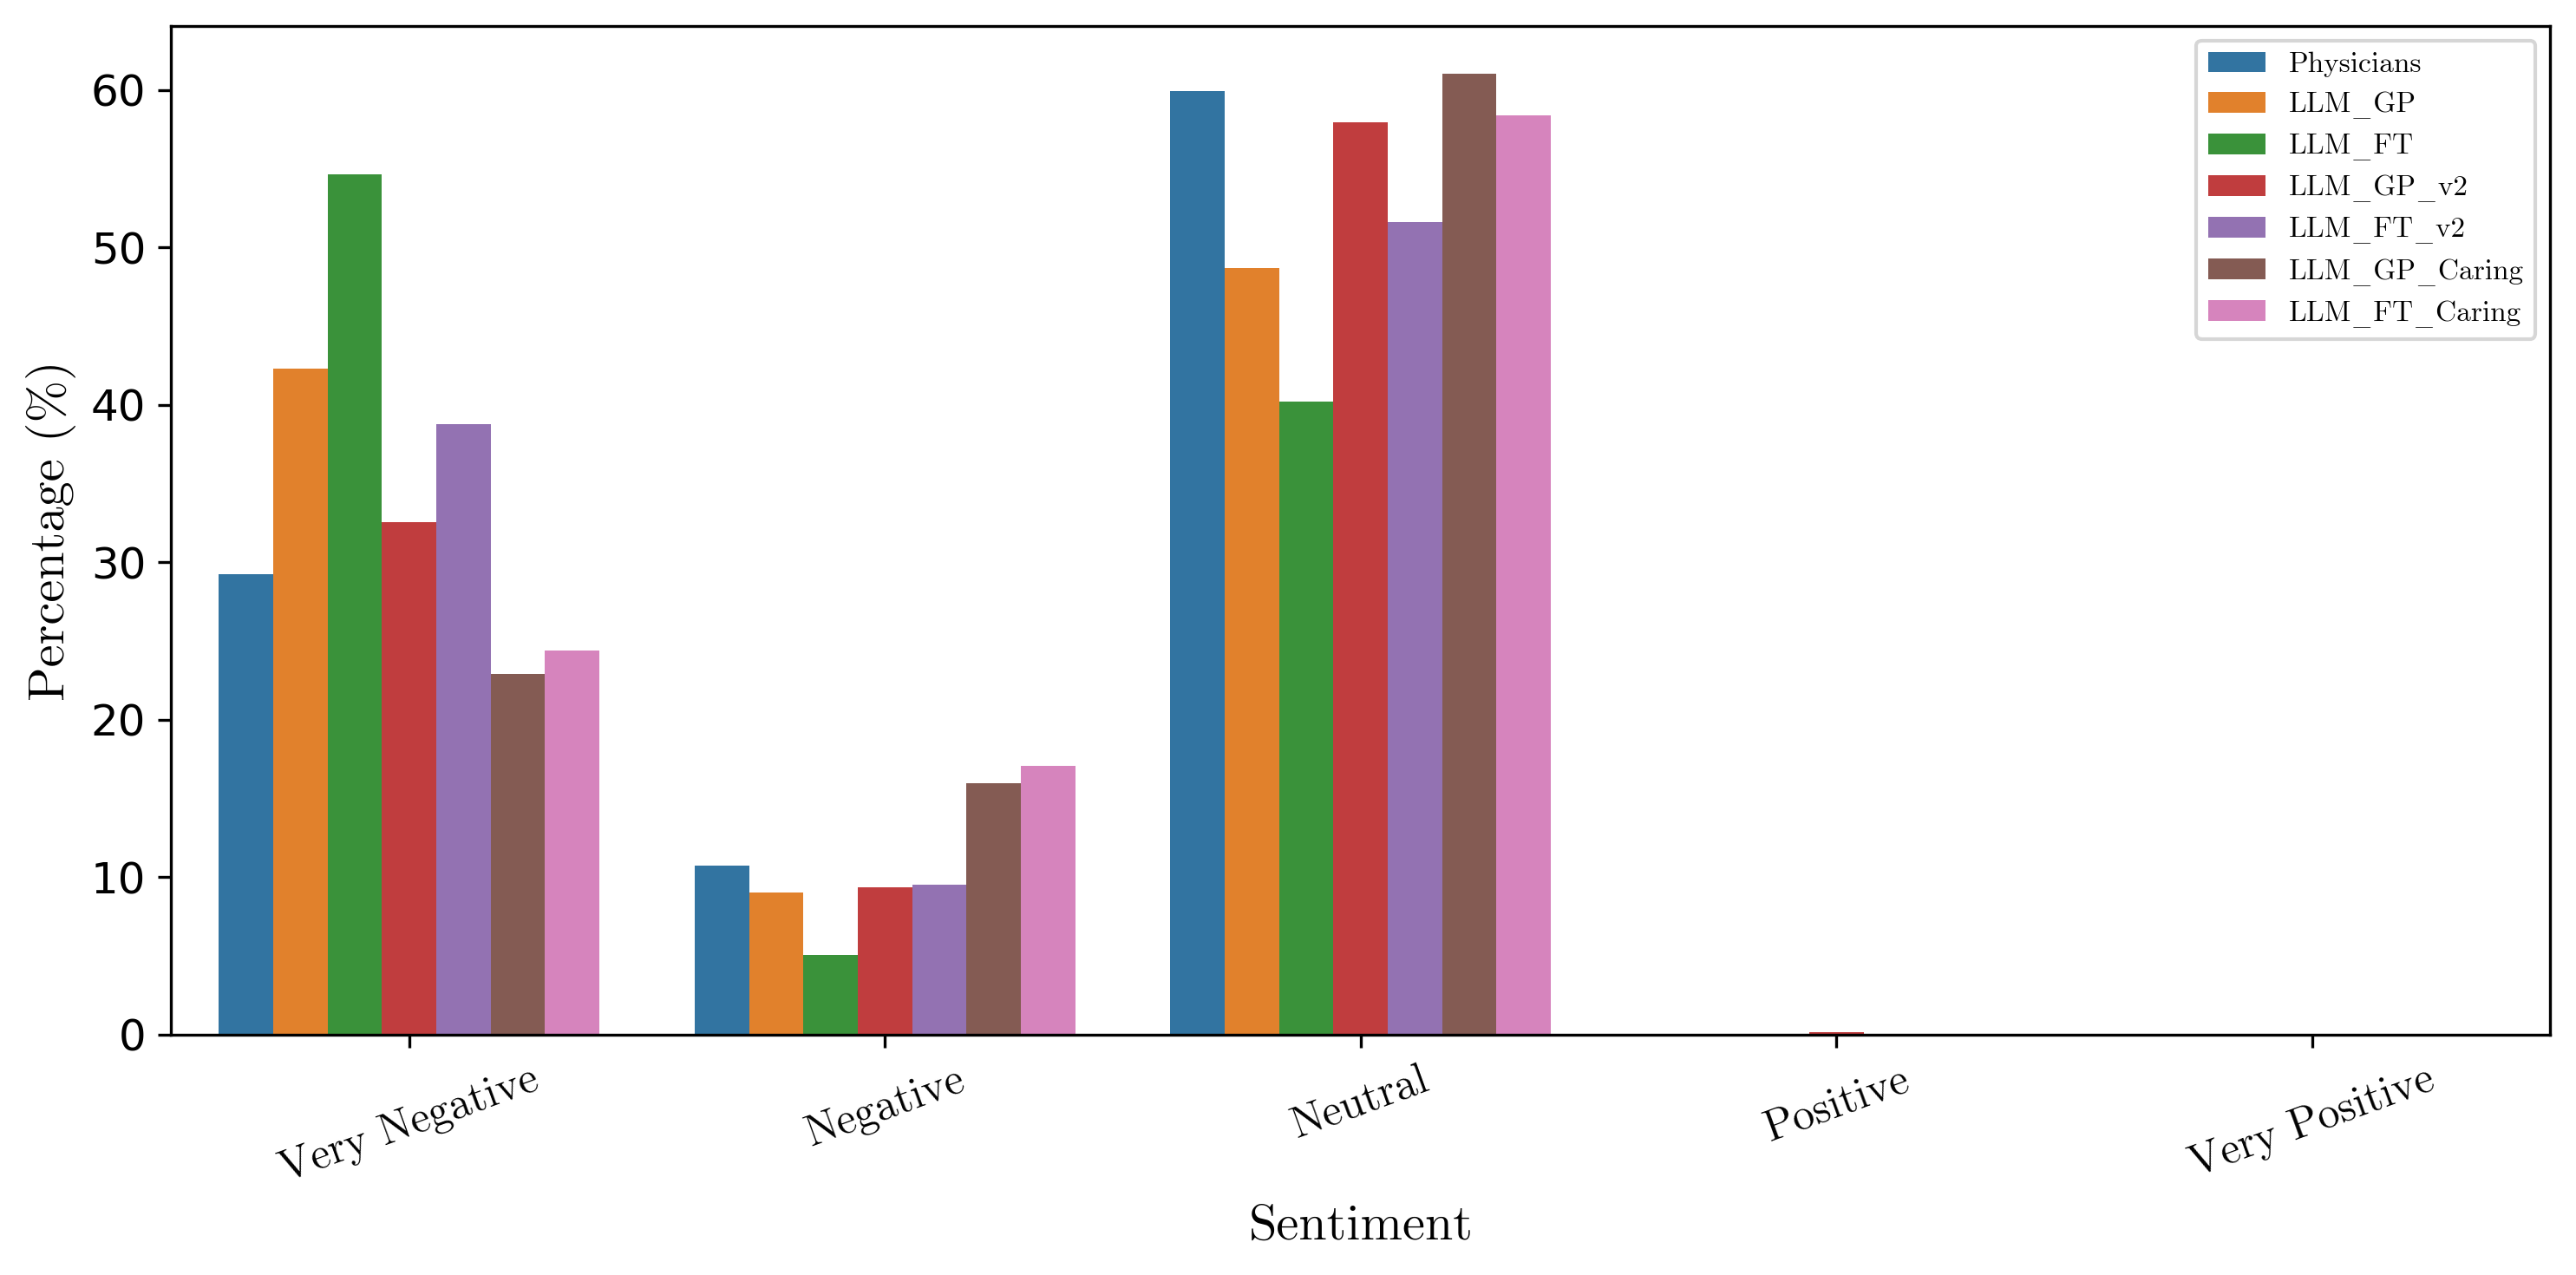

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib import font_manager as fm
import matplotlib as mpl

# === Disabilita unicode minus ===
mpl.rcParams['axes.unicode_minus'] = False

# === FUNZIONE PER IL FONT ===
def use_custom_font(font_path: str):
    import matplotlib as mpl
    from matplotlib import font_manager as fm
    mpl.rcdefaults()
    return fm.FontProperties(fname=font_path)

# === CARICA FONT ===
font_path = "/content/fonts/cmunrm.ttf"
cmu_font = use_custom_font(font_path)
fallback_font = fm.FontProperties(family="DejaVu Sans")

# === DIMENSIONI FONT ===
title_fontsize = 20
xtick_fontsize = 12
ytick_fontsize = 12
xlabel_fontsize = 14
ylabel_fontsize = 14
legend_fontsize = 8

cmu_font_title = cmu_font.copy(); cmu_font_title.set_size(title_fontsize)
cmu_font_xtick = cmu_font.copy(); cmu_font_xtick.set_size(xtick_fontsize)
cmu_font_ytick = fallback_font.copy(); cmu_font_ytick.set_size(ytick_fontsize)
cmu_font_xlabel = cmu_font.copy(); cmu_font_xlabel.set_size(xlabel_fontsize)
cmu_font_ylabel = cmu_font.copy(); cmu_font_ylabel.set_size(ylabel_fontsize)
cmu_font_legend = cmu_font.copy(); cmu_font_legend.set_size(legend_fontsize)

# === ETICHETTE DEI SENTIMENTI ===
sentiment_labels = ["Very Negative", "Negative", "Neutral", "Positive", "Very Positive"]

# === RICOSTRUZIONE DELLA TABELLA DI CONTINGENZA ===
contingency = pd.DataFrame({
    "Physicians": df["Sentiment_medico"].value_counts().reindex(sentiment_labels, fill_value=0),
    "LLM_GP": df["Sentiment_LLM"].value_counts().reindex(sentiment_labels, fill_value=0),
    "LLM_FT": df["Sentiment_LLM_PALMYRA"].value_counts().reindex(sentiment_labels, fill_value=0),
    "LLM_GP_v2": df["Sentiment_LLM_prompt2"].value_counts().reindex(sentiment_labels, fill_value=0),
    "LLM_FT_v2": df["Sentiment_LLM_PALMYRA_prompt2"].value_counts().reindex(sentiment_labels, fill_value=0),
    "LLM_GP_Caring": df["Sentiment_CARING_LLM"].value_counts().reindex(sentiment_labels, fill_value=0),
    "LLM_FT_Caring": df["Sentiment_CARING_PALMYRA"].value_counts().reindex(sentiment_labels, fill_value=0)
})

# === TRASFORMAZIONE IN PERCENTUALI ===
contingency_percent = contingency.divide(contingency.sum(axis=0), axis=1) * 100

# === PREPARAZIONE DATI PER SEABORN ===
df_melted = contingency_percent.reset_index().melt(id_vars="index", var_name="System", value_name="Percentage")
df_melted.rename(columns={"index": "Sentiment"}, inplace=True)

# === GRAFICO ===
plt.figure(figsize=(10, 5), dpi=300)
sns.barplot(data=df_melted, x="Sentiment", y="Percentage", hue="System")

plt.xlabel("Sentiment", fontproperties=cmu_font_xlabel)
plt.ylabel("Percentage (%)", fontproperties=cmu_font_ylabel)
plt.xticks(rotation=20, fontproperties=cmu_font_xtick)
plt.yticks(fontproperties=cmu_font_ytick)

plt.legend(title=None, loc="best", prop=cmu_font_legend)
plt.tight_layout()

# === SALVATAGGIO ===
plt.savefig("sentiment_distribution_barplot_gp_ft.pdf")
plt.show()


In [ ]:
print(df_melted)


        Sentiment          Legend  Percentage
0   Very Negative          Doctor   29.231426
1        Negative          Doctor   10.733224
2         Neutral          Doctor   59.931736
3        Positive          Doctor    0.067045
4   Very Positive          Doctor    0.036570
5   Very Negative         Mixtral   42.305114
6        Negative         Mixtral    9.008350
7         Neutral         Mixtral   48.686536
8        Positive         Mixtral    0.000000
9   Very Positive         Mixtral    0.000000
10  Very Negative         PALMYRA   54.665691
11       Negative         PALMYRA    5.083196
12        Neutral         PALMYRA   40.238922
13       Positive         PALMYRA    0.012190
14  Very Positive         PALMYRA    0.000000
15  Very Negative       Mixtral_2   32.540989
16       Negative       Mixtral_2    9.349668
17        Neutral       Mixtral_2   57.969160
18       Positive       Mixtral_2    0.134089
19  Very Positive       Mixtral_2    0.006095
20  Very Negative       PALMYRA_2 

In [ ]:
# prompt: mostrami il contenuto di df delle colonne   55  Answer_medico_caring_LLM_emotions               16407 non-null  object
#  56  Answer_medico_caring_LLM_PALMYRA_emotions       16407 non-null  object  437  Sentiment_CARING_LLM                            16407 non-null  object
#  48  Sentiment_CARING_PALMYRA                        16407 non-null  object

print(df[['Answer_medico_caring_LLM_emotions', 'Answer_medico_caring_LLM_PALMYRA_emotions', 'Sentiment_CARING_LLM', 'Sentiment_CARING_PALMYRA']].to_string())


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
df

,context,question,Answer_medico,Answer_LLM,Answer_LLM_PALMYRA,Sentiment_medico,Sentiment_LLM,Sentiment_LLM_PALMYRA,Answer_medico_concepts,Answer_LLM_concepts,...,Sentiment_CARING_LLM,Sentiment_CARING_PALMYRA,Length_Answer_medico_caring_LLM,Length_Answer_medico_caring_LLM_PALMYRA,Answer_medico_caring_LLM_FleschKincaid,Answer_medico_caring_LLM_GunningFog,Answer_medico_caring_LLM_PALMYRA_FleschKincaid,Answer_medico_caring_LLM_PALMYRA_GunningFog,Answer_medico_caring_LLM_emotions,Answer_medico_caring_LLM_PALMYRA_emotions
0,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,LCMV infections can occur after exposure to fr...,Lymphocytic Choriomeningitis (LCM) is a viral ...,Individuals who are at risk for Lymphocytic Ch...,Very Negative,Very Negative,Negative,LCMV exposure to fresh urine droppings saliva ...,Lymphocytic Choriomeningitis LCM viral infecti...,...,Neutral,Neutral,85,65,14.3,15.56,10.6,11.76,"{'neutral': np.float64(0.8437), 'approval': np...","{'neutral': np.float64(0.8495), 'approval': np..."
1,symptoms,What are the symptoms of Lymphocytic Choriomen...,LCMV is most commonly recognized as causing ne...,Lymphocytic Choriomeningitis (LCM) is a viral ...,Lymphocytic Choriomeningitis (LCM) is a viral ...,Negative,Neutral,Very Negative,LCMV neurological disease implies infection sy...,Lymphocytic Choriomeningitis LCM viral infecti...,...,Very Negative,Neutral,299,157,9.4,9.89,8.9,10.27,"{'neutral': np.float64(0.7274), 'sadness': np....","{'neutral': np.float64(0.4589), 'sadness': np...."
2,susceptibility,Who is at risk for Lymphocytic Choriomeningiti...,Individuals of all ages who come into contact ...,Individuals at risk for Lymphocytic Choriomeni...,Individuals who are at risk for Lymphocytic Ch...,Very Negative,Very Negative,Negative,Individuals ages contact with urine feces sali...,Individuals risk Lymphocytic Choriomeningitis ...,...,Very Negative,Very Negative,103,93,13.4,15.76,12.4,13.62,"{'neutral': np.float64(0.7707), 'approval': np...","{'neutral': np.float64(0.7499), 'approval': np..."
3,exams and tests,How to diagnose Lymphocytic Choriomeningitis (...,"During the first phase of the disease, the mos...",Lymphocytic Choriomeningitis (LCM) is typicall...,To diagnose Lymphocytic Choriomeningitis (LCM)...,Negative,Neutral,Neutral,phase disease laboratory abnormalities white b...,Lymphocytic Choriomeningitis LCM diagnosed cli...,...,Neutral,Neutral,118,93,12.5,13.85,12.4,12.33,"{'neutral': np.float64(0.8408), 'realization':...","{'neutral': np.float64(0.866), 'approval': np...."
4,treatment,What are the treatments for Lymphocytic Chorio...,"Aseptic meningitis, encephalitis, or meningoen...",Lymphocytic Choriomeningitis (LCM) is a viral ...,Lymphocytic Choriomeningitis (LCM) is a viral ...,Neutral,Neutral,Neutral,Aseptic meningitis encephalitis meningoencepha...,Lymphocytic Choriomeningitis LCM viral infecti...,...,Neutral,Neutral,66,72,10.9,13.87,9.1,10.53,"{'neutral': np.float64(0.6481), 'approval': np...","{'caring': np.float64(0.8521), 'neutral': np.f..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16402,symptoms,What are the symptoms of Familial visceral myo...,What are the signs and symptoms of Familial vi...,Familial visceral myopathy with external ophth...,Familial visceral myopathy with external ophth...,Neutral,Very Negative,Very Negative,signs symptoms Familial visceral myopathy exte...,Familial visceral myopathy external ophthalmop...,...,Neutral,Neutral,307,100,12.5,13.38,9.8,11.48,"{'neutral': np.float64(0.7713), 'curiosity': n...","{'neutral': np.float64(0.7105), 'sadness': np...."
16403,information,What is (are) Pseudopelade of Brocq ?,Pseudopelade of Brocq (PBB) is a slowly progre...,Pseudopelade of Brocq is a rare type of scarri...,"Pseudopelade of Brocq is a rare, chronic, and ...",Neutral,Very Negative,Very Negative,Pseudopelade Brocq PBB progressive chronic con...,Pseudopelade Brocq scarring alopecia group con...,...,Neutral,Neutral,153,115,10.

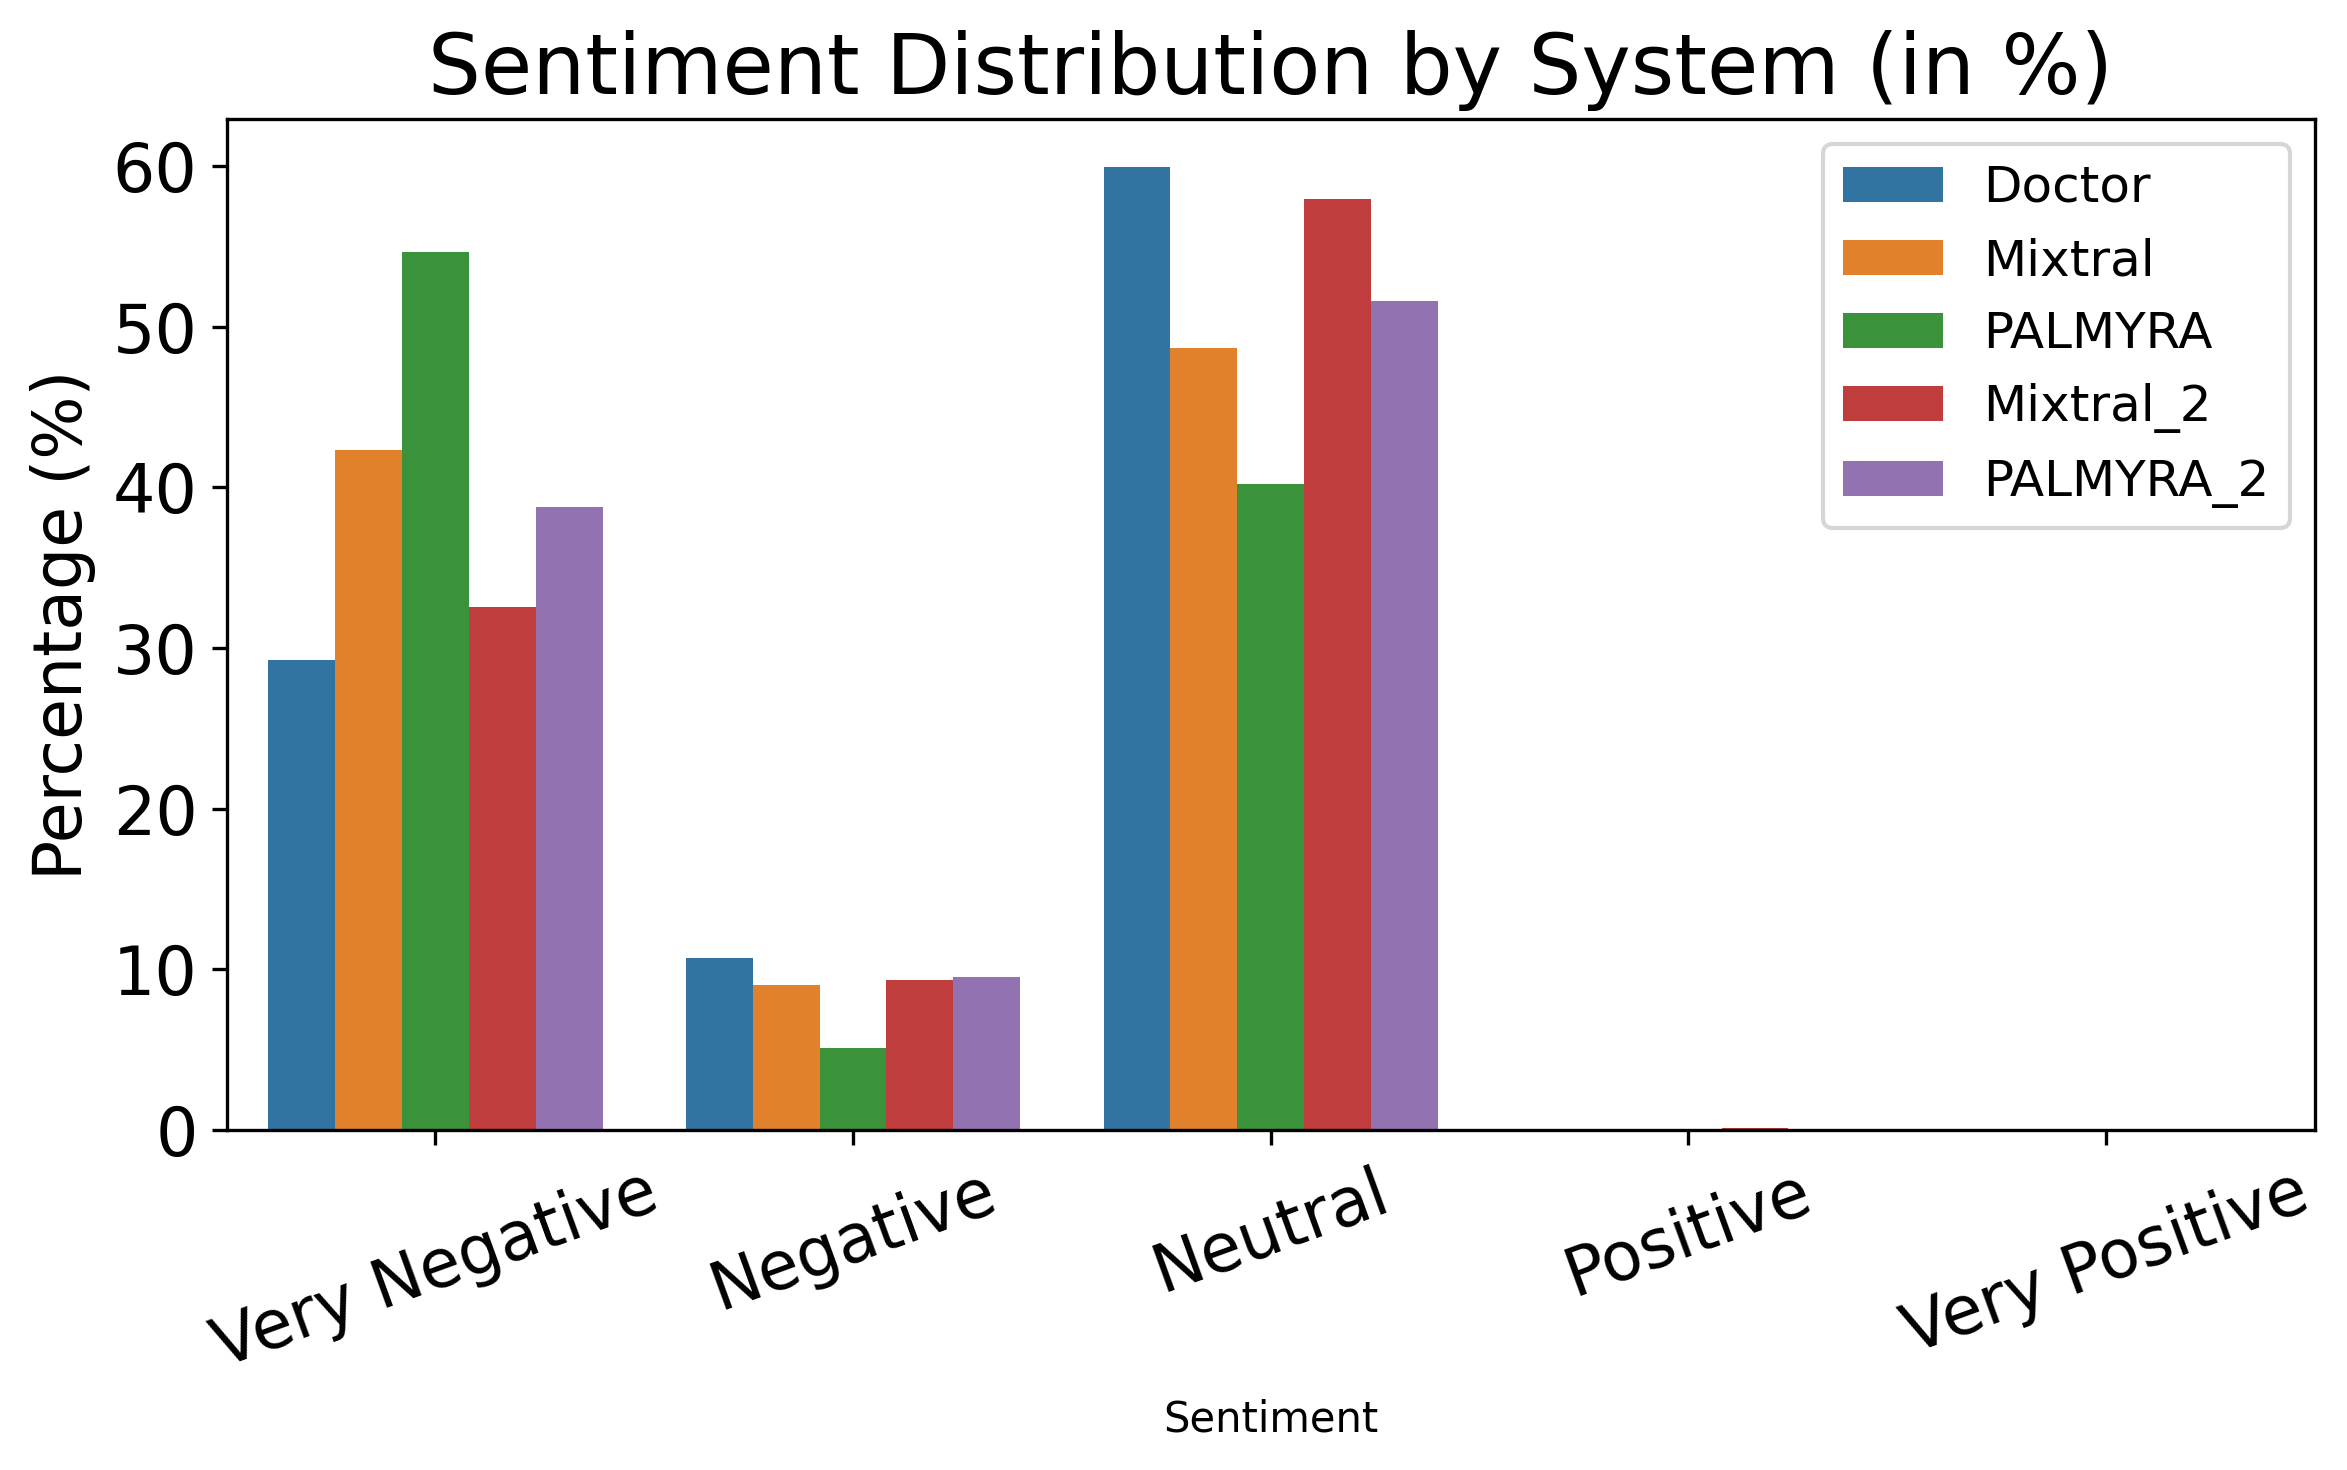

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# === PARAMETRI DI STILE ===
title_fontsize = 20
xtick_fontsize = 16
ytick_fontsize = 16
ylabel_fontsize = 16
legend_fontsize = 12

# Ricostruzione della tabella di contingenza per il plot
sentiment_labels = ["Very Negative", "Negative", "Neutral", "Positive", "Very Positive"]
contingency = pd.DataFrame({
    "Doctor": df["Sentiment_medico"].value_counts().reindex(sentiment_labels, fill_value=0),
    "Mixtral": df["Sentiment_LLM"].value_counts().reindex(sentiment_labels, fill_value=0),
    "PALMYRA": df["Sentiment_LLM_PALMYRA"].value_counts().reindex(sentiment_labels, fill_value=0),
    "Mixtral_2": df["Sentiment_LLM_prompt2"].value_counts().reindex(sentiment_labels, fill_value=0),
    "PALMYRA_2": df["Sentiment_LLM_PALMYRA_prompt2"].value_counts().reindex(sentiment_labels, fill_value=0)
})

# Trasformazione in percentuale per ogni colonna
contingency_percent = contingency.divide(contingency.sum(axis=0), axis=1) * 100

# Reset index per compatibilità con Seaborn
df_melted = contingency_percent.reset_index().melt(id_vars="index", var_name="Legend", value_name="Percentage")
df_melted.rename(columns={"index": "Sentiment"}, inplace=True)

# Creazione del grafico
plt.figure(figsize=(8, 5), dpi=300)
sns.barplot(data=df_melted, x="Sentiment", y="Percentage", hue="Legend")

# Titolo e assi
plt.title("Sentiment Distribution by System (in %)", fontsize=title_fontsize)
plt.ylabel("Percentage (%)", fontsize=ylabel_fontsize)
plt.xticks(rotation=20, fontsize=xtick_fontsize)
plt.yticks(fontsize=ytick_fontsize)

# Legenda
plt.legend(title=None, loc="best", fontsize=legend_fontsize)

plt.tight_layout()

# Salvataggio del grafico
plot_path = "sentiment_distribution_barplot.pdf"
plt.savefig(plot_path)
plt.show()


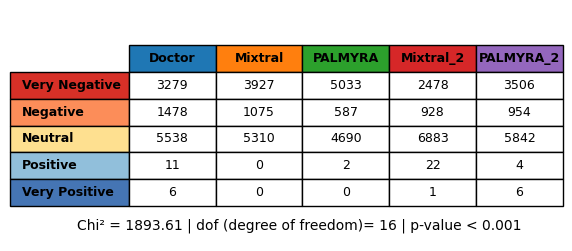

'sentiment_table_final_colored.pdf'

In [ ]:
# Ricreazione della tabella con i colori spostati sulla colonna delle etichette (sentimenti)

import matplotlib.pyplot as plt
import pandas as pd

# Dati riordinati per ordine crescente di positività
data = {
    "Doctor": [3279, 1478, 5538, 11, 6],
    "Mixtral": [3927, 1075, 5310, 0, 0],
    "PALMYRA": [5033, 587, 4690, 2, 0],
    "Mixtral_2": [2478, 928, 6883, 22, 1],
    "PALMYRA_2": [3506, 954, 5842, 4, 6]
}
sentiments = ["Very Negative", "Negative", "Neutral", "Positive", "Very Positive"]
df_table = pd.DataFrame(data, index=sentiments)

# Colori intestazioni colonne
column_colors = {
    "Doctor": "#1f77b4",
    "Mixtral": "#ff7f0e",
    "PALMYRA": "#2ca02c",
    "Mixtral_2": "#d62728",
    "PALMYRA_2": "#9467bd"
}

# Colori per etichette riga: Very Negative → Very Positive
row_colors = ["#d73027", "#fc8d59", "#fee090", "#91bfdb", "#4575b4"]

# Creazione della figura e della tabella
fig, ax = plt.subplots(figsize=(4, 3))
ax.axis('off')
table = ax.table(
    cellText=df_table.values,
    colLabels=df_table.columns,
    rowLabels=df_table.index,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.4, 1.6)

# Colora intestazioni colonne (sistemi)
for i, col in enumerate(df_table.columns):
    table[(0, i )].set_facecolor(column_colors[col])
    table[(0, i )].set_text_props(weight='bold', color='black')

# Colora la colonna delle etichette (Very Negative → Very Positive)

for j, sentiment in enumerate(sentiments):
    table[(j + 1, -1)].set_facecolor(row_colors[j])
    table[(j + 1, -1)].set_text_props(weight='bold', color='black')

# Aggiunta del testo del Chi-quadro sotto la tabella
chi2_stat = 1893.61
dof = 16
p_value = 0.0

chi2_text = f"Chi² = {chi2_stat:.2f} | dof (degree of freedom)= {dof} | p-value < 0.001"

plt.text(0.35, 0.05 , chi2_text,
         fontsize=10,
         ha='center',
         transform=ax.transAxes)


# Salvataggio
png_path = "sentiment_table_final_colored.pdf"
plt.show()
plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.close()

png_path


In [6]:
import pandas as pd
import ast

# Parsing e conteggio emozioni da stringhe JSON-like o dizionari (Answer_*_emotions)
emotion_cols = [
    "Answer_medico_emotions",
    "Answer_LLM_emotions",
    "Answer_LLM_PALMYRA_emotions",
    "Answer_LLM_prompt2_emotions",
    "Answer_LLM_PALMYRA_prompt2_emotions"
]

# Funzione di parsing sicuro
def parse_emotion(entry):
    if pd.isna(entry) or entry in ["", "null"]:
        return {}
    try:
        return ast.literal_eval(entry)
    except Exception:
        return {}

# Applichiamo il parsing per ciascuna colonna e creiamo DataFrame dei conteggi
emotion_counts = {}
for col in emotion_cols:
    parsed = df[col].apply(parse_emotion)
    all_emotions = parsed.explode().dropna()
    emotion_flat = parsed.apply(lambda d: list(d.keys()) if isinstance(d, dict) else d)
    flat_counts = pd.Series([e for sublist in emotion_flat.dropna() for e in sublist])
    emotion_counts[col] = flat_counts.value_counts()

# Creazione tabella di contingenza
emotion_df = pd.DataFrame(emotion_counts).fillna(0).astype(int)

# Riorganizza i nomi per chiarezza
emotion_df.columns = [
    "Doctor", "Mixtral", "PALMYRA", "Mixtral_2", "PALMYRA_2"
]

# Esegui test Chi-quadro
from scipy.stats import chi2_contingency

chi2_stat, p_val, dof, expected = chi2_contingency(emotion_df)

# Risultati del test
chi2_result = {
    "Chi2 Statistic": chi2_stat,
    "Degrees of Freedom": dof,
    "p-value": p_val
}

emotion_df, chi2_result


ValueError: No data; `observed` has size 0.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16407 entries, 0 to 16406
Data columns (total 59 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Unnamed: 0                                      16407 non-null  int64  
 1   context                                         16407 non-null  object 
 2   question                                        16407 non-null  object 
 3   Answer_medico                                   16407 non-null  object 
 4   Answer_LLM                                      16407 non-null  object 
 5   Answer_LLM_PALMYRA                              16407 non-null  object 
 6   Sentiment_medico                                16407 non-null  object 
 7   Sentiment_LLM                                   16407 non-null  object 
 8   Sentiment_LLM_PALMYRA                           16407 non-null  object 
 9   Answer_medico_concepts                 

In [ ]:
import pandas as pd

# Lista delle colonne con le emozioni
emotion_cols = [
    "Answer_medico_emotions",
    "Answer_LLM_emotions",
    "Answer_LLM_PALMYRA_emotions",
    "Answer_LLM_prompt2_emotions",
    "Answer_LLM_PALMYRA_prompt2_emotions",
    "Answer_medico_caring_LLM_emotions",
    "Answer_medico_caring_LLM_PALMYRA_emotions"
]

# Stampa dei primi 3 esempi non nulli per colonna
for col in emotion_cols:
    print(f"\n🔍 Colonna: {col}")
    non_null_values = df[col].dropna().astype(str).unique()[:3]
    for i, val in enumerate(non_null_values, 1):
        print(f"  Esempio {i}: {val}")


In [ ]:
df.head

<bound method NDFrame.head of                context                                           question  \
0       susceptibility  Who is at risk for Lymphocytic Choriomeningiti...   
1             symptoms  What are the symptoms of Lymphocytic Choriomen...   
2       susceptibility  Who is at risk for Lymphocytic Choriomeningiti...   
3      exams and tests  How to diagnose Lymphocytic Choriomeningitis (...   
4            treatment  What are the treatments for Lymphocytic Chorio...   
...                ...                                                ...   
10307        treatment  What are the treatments for Sjgren-Larsson syn...   
10308      information  What is (are) CHMP2B-related frontotemporal de...   
10309        frequency  How many people are affected by CHMP2B-related...   
10310  genetic changes  What are the genetic changes related to CHMP2B...   
10311      inheritance  Is CHMP2B-related frontotemporal dementia inhe...   

                                           Answer_medico  \
0      LCMV infections can occur after exposure to fr...   
1      LCMV is most commonly recognized as causing ne...   
2      Individuals of all ages who come into contact ...   
3      During the first phase of the disease, the mos...   
4      Aseptic meningitis, encephalitis, or meningoen...   
...                                                  ...   
10307  These resources address the diagnosis or manag...   
10308  CHMP2B-related frontotemporal dementia is a pr...   
10309  CHMP2B-related frontotemporal dementia has bee...   
10310  CHMP2B-related frontotemporal dementia results...   
10311  This condition is inherited in an autosomal do...   

                                              Answer_LLM  \
0      Lymphocytic Choriomeningitis (LCM) is a viral ...   
1      Lymphocytic Choriomeningitis (LCM) is a viral ...   
2      Individuals at risk for Lymphocytic Choriomeni...   
3      Lymphocytic Choriomeningitis (LCM) is typicall...   
4      Lymphocytic Choriomeningitis (LCM) is a viral ...   
...                                                  ...   
10307  Sjögren-Larsson syndrome (SLS) is a rare autos...   
10308  CHMP2B-related frontotemporal dementia (FTD) i...   
10309  CHMP2B-related frontotemporal dementia (FTD) i...   
10310  CHMP2B-related frontotemporal dementia (FTD) i...   
10311  CHMP2B-related frontotemporal dementia is inde...   

                                      Answer_LLM_PALMYRA Sentiment_medico  \
0      Individuals who are at risk for Lymphocytic Ch...    Very Negative   
1      Lymphocytic Choriomeningitis (LCM) is a viral ...         Negative   
2      Individuals who are at risk for Lymphocytic Ch...    Very Negative   
3      To diagnose Lymphocytic Choriomeningitis (LCM)...         Negative   
4      Lymphocytic Choriomeningitis (LCM) is a viral ...          Neutral   
...                                                  ...              ...   
10307  Sjögren-Larsson syndrome is a rare genetic dis...          Neutral   
10308  CHMP2B-related frontotemporal dementia is a ra...    Very Negative   
10309  CHMP2B-related frontotemporal dementia is a ra...          Neutral   
10310  CHMP2B-related frontotemporal dementia is asso...    Very Negative   
10311  CHMP2B-related frontotemporal dementia is a ra...          Neutral   

       Sentiment_LLM Sentiment_LLM_PALMYRA  \
0      Very Negative              Negative   
1            Neutral         Very Negative   
2      Very Negative              Negative   
3            Neutral               Neutral   
4            Neutral               Neutral   
...              ...                   ...   
10307        Neutral               Neutral   
10308  Very Negative         Very Negative   
10309        Neutral               Neutral   
10310  Very Negative         Very Negative   
10311        Neutral         Very Negative   

                                  Answer_medico_concepts  \
0      LCMV exposure to fresh urine droppings saliva ...   
1    

In [ ]:
import re
import ast

def clean_and_get_dominant_emotion(raw):
    try:
        # Rimuovi "np.float64(" e ")" da ogni valore
        cleaned = re.sub(r'np\.float64\((.*?)\)', r'\1', str(raw))
        d = ast.literal_eval(cleaned)
        if isinstance(d, dict) and d:
            return max(d.items(), key=lambda item: item[1])[0]
    except:
        pass
    return None


In [ ]:
dominant_df = pd.DataFrame()
for col in emotion_cols:
    dominant_df[col] = df[col].dropna().apply(clean_and_get_dominant_emotion)


In [ ]:
dominant_df

,Answer_medico_emotions,Answer_LLM_emotions,Answer_LLM_PALMYRA_emotions,Answer_LLM_prompt2_emotions,Answer_LLM_PALMYRA_prompt2_emotions
0,neutral,neutral,neutral,neutral,neutral
1,neutral,caring,caring,caring,neutral
2,neutral,neutral,neutral,neutral,neutral
3,neutral,neutral,neutral,neutral,neutral
4,neutral,neutral,neutral,caring,caring
...,...,...,...,...,...
16402,neutral,neutral,neutral,caring,caring
16403,confusion,neutral,neutral,neutral,neutral
16404,neutral,neutral,neutral,neutral,neutral
16405,neutral,neutral,neutral,caring,caring


In [ ]:
for col in dominant_df.columns:
    print(f"\n🔍 Emozioni prevalenti in {col}")
    print(dominant_df[col].value_counts(normalize=True).round(3))



🔍 Emozioni prevalenti in Answer_medico_emotions
Answer_medico_emotions
neutral           0.936
confusion         0.035
curiosity         0.012
caring            0.010
sadness           0.002
approval          0.002
disapproval       0.000
optimism          0.000
fear              0.000
nervousness       0.000
joy               0.000
embarrassment     0.000
realization       0.000
disappointment    0.000
Name: proportion, dtype: float64

🔍 Emozioni prevalenti in Answer_LLM_emotions
Answer_LLM_emotions
neutral        0.955
caring         0.036
approval       0.005
confusion      0.003
sadness        0.001
optimism       0.001
nervousness    0.000
fear           0.000
gratitude      0.000
disapproval    0.000
Name: proportion, dtype: float64

🔍 Emozioni prevalenti in Answer_LLM_PALMYRA_emotions
Answer_LLM_PALMYRA_emotions
neutral           0.954
caring            0.026
approval          0.011
confusion         0.005
sadness           0.002
optimism          0.001
nervousness       0.001


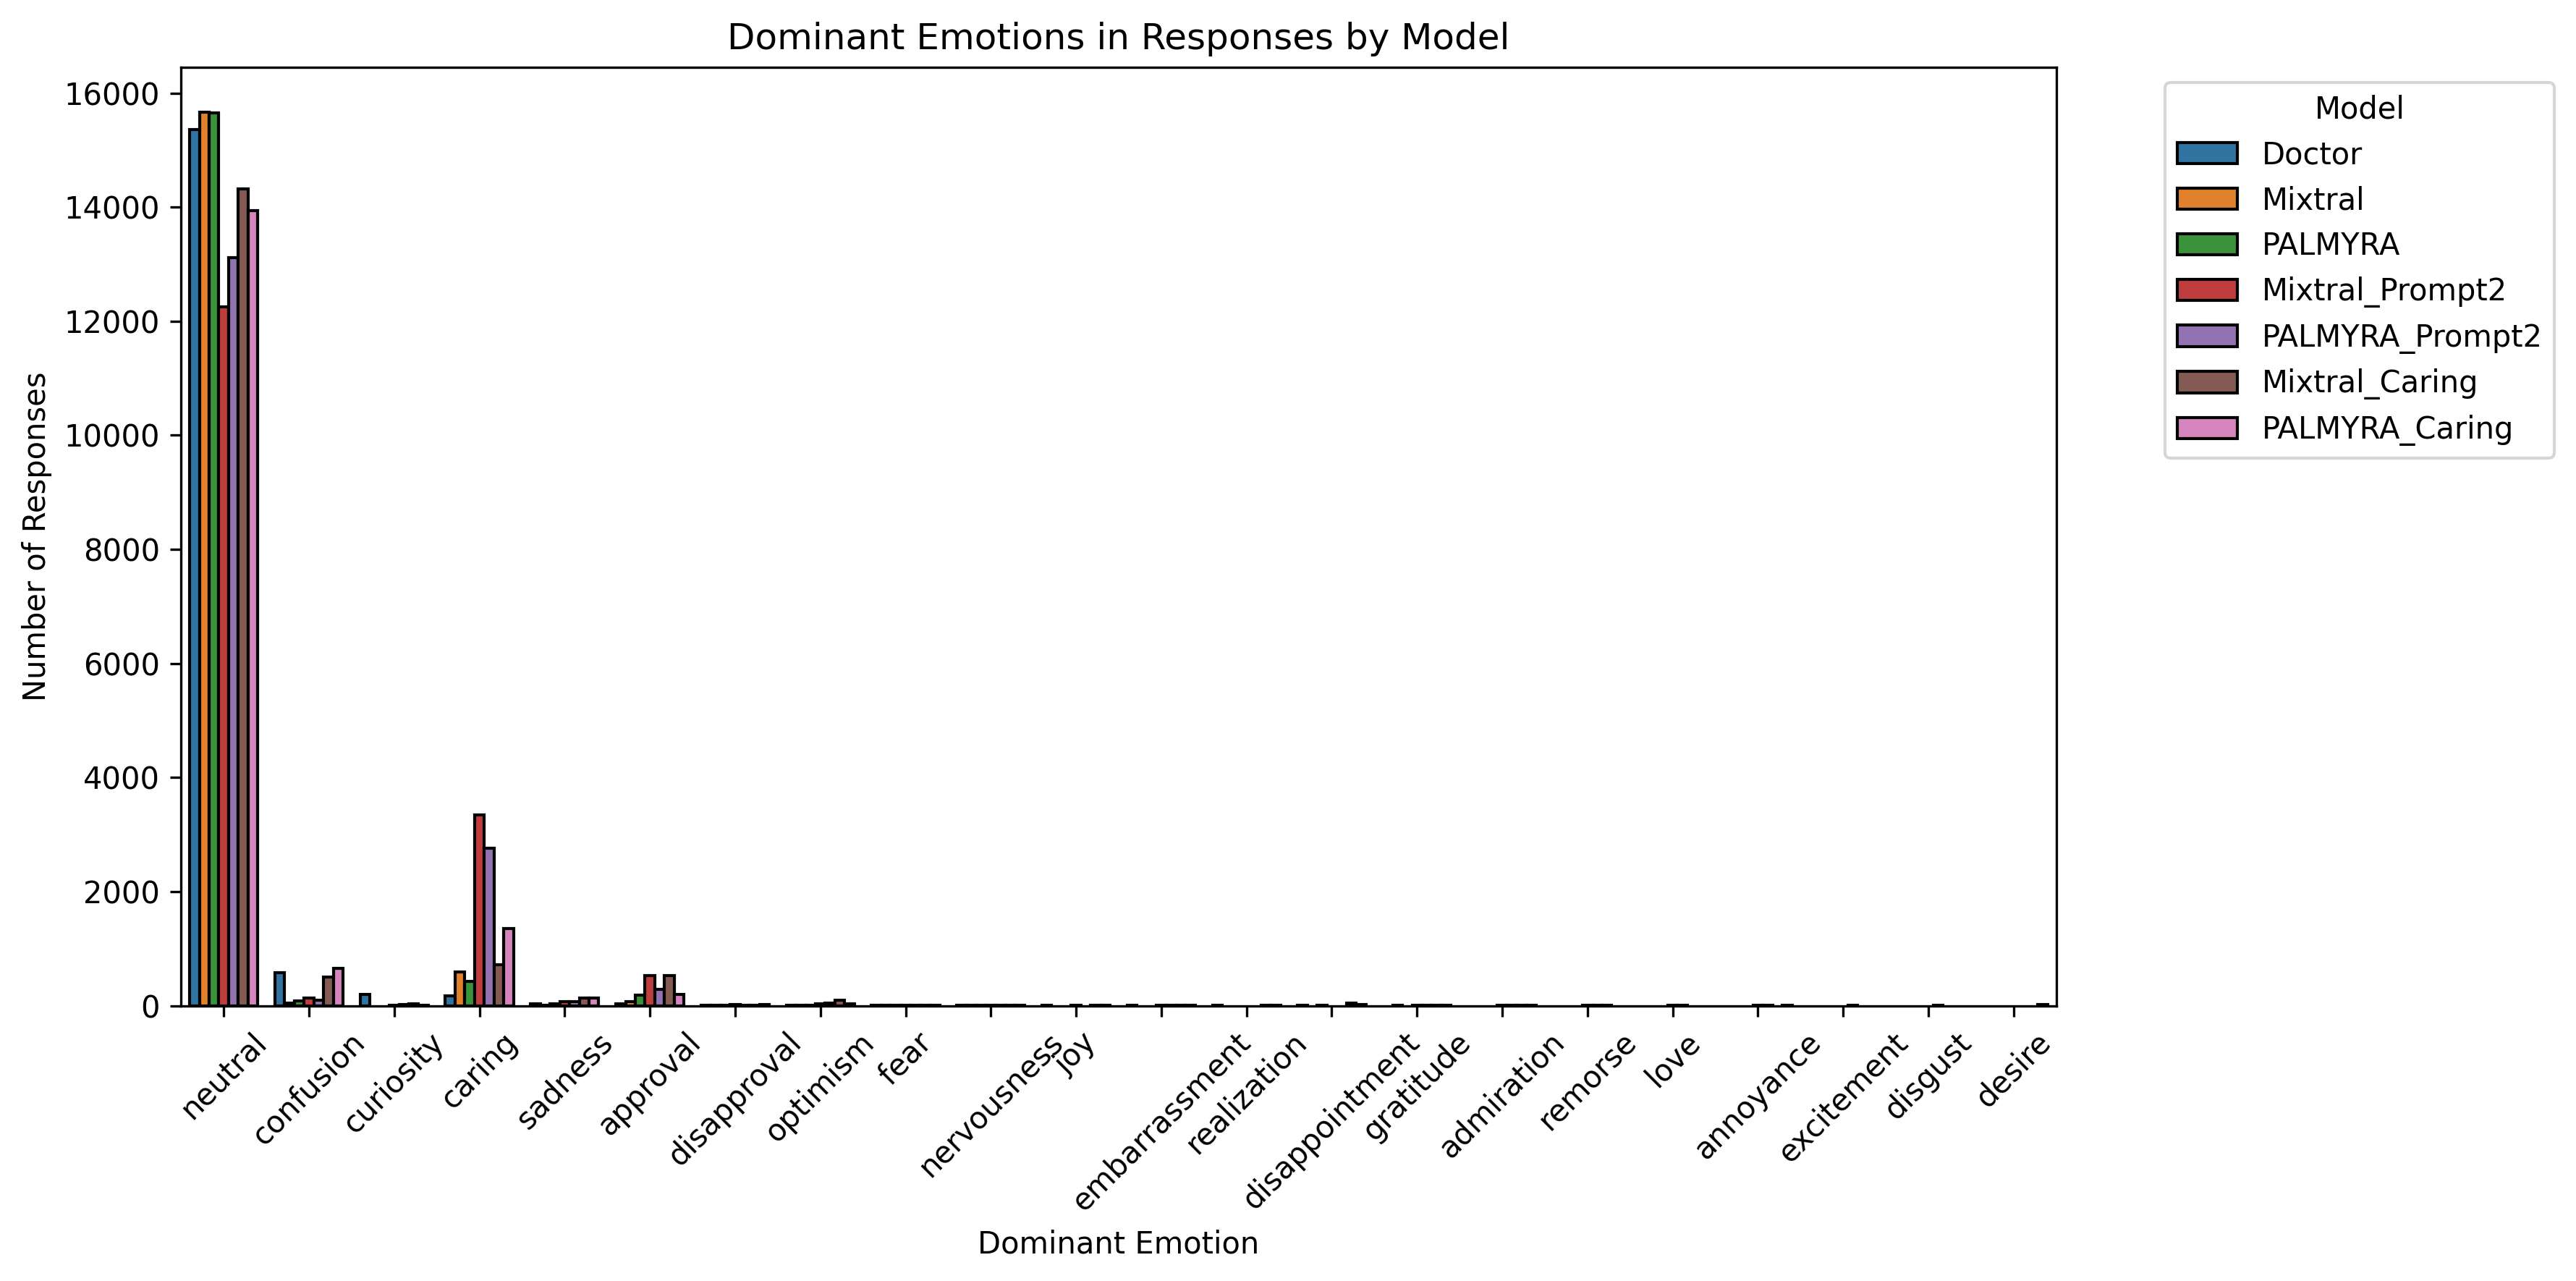


📊 Chi-Squared Test on Dominant Emotion Distributions
Chi² statistic = 11667.05
Degrees of freedom = 126
p-value = 0.0000e+00
Significant difference among models?  ✅ Yes


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
from collections import Counter
from scipy.stats import chi2_contingency

# Colonne delle emozioni mappate a nomi leggibili
emotion_cols = {
    "Answer_medico_emotions": "Doctor",
    "Answer_LLM_emotions": "Mixtral",
    "Answer_LLM_PALMYRA_emotions": "PALMYRA",
    "Answer_LLM_prompt2_emotions": "Mixtral_Prompt2",
    "Answer_LLM_PALMYRA_prompt2_emotions": "PALMYRA_Prompt2",
    "Answer_medico_caring_LLM_emotions": "Mixtral_Caring",
    "Answer_medico_caring_LLM_PALMYRA_emotions": "PALMYRA_Caring"
}

# Funzione robusta per estrarre l’emozione dominante
def extract_dominant_emotion(x):
    try:
        # Rimuove 'np.float64(...)'
        cleaned = re.sub(r'np\.float64\((.*?)\)', r'\1', str(x))
        d = ast.literal_eval(cleaned)
        if isinstance(d, dict) and d:
            return max(d.items(), key=lambda item: item[1])[0]
    except Exception:
        pass
    return None

# Lista di tutte le emozioni dominanti per ciascun modello
dominant_emotions = []

for col, label in emotion_cols.items():
    dominant = df[col].dropna().apply(extract_dominant_emotion)
    counts = dominant.value_counts()
    for emotion, freq in counts.items():
        dominant_emotions.append({
            "Model": label,
            "Emotion": emotion,
            "Frequency": freq
        })

# Costruisci DataFrame
dominant_df = pd.DataFrame(dominant_emotions)

# Plot
plt.figure(figsize=(12, 6), dpi=300)
sns.barplot(data=dominant_df, x="Emotion", y="Frequency", hue="Model", edgecolor='black')
plt.title("Dominant Emotions in Responses by Model")
plt.xlabel("Dominant Emotion")
plt.ylabel("Number of Responses")
plt.xticks(rotation=45)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("dominant_emotions_by_model.pdf", format="pdf", dpi=300)
plt.show()

# Test chi²
pivot = dominant_df.pivot_table(index="Model", columns="Emotion", values="Frequency", fill_value=0)
chi2, p, dof, expected = chi2_contingency(pivot)

print("\n📊 Chi-Squared Test on Dominant Emotion Distributions")
print(f"Chi² statistic = {chi2:.2f}")
print(f"Degrees of freedom = {dof}")
print(f"p-value = {p:.4e}")
print("Significant difference among models? ", "✅ Yes" if p < 0.05 else "❌ No")


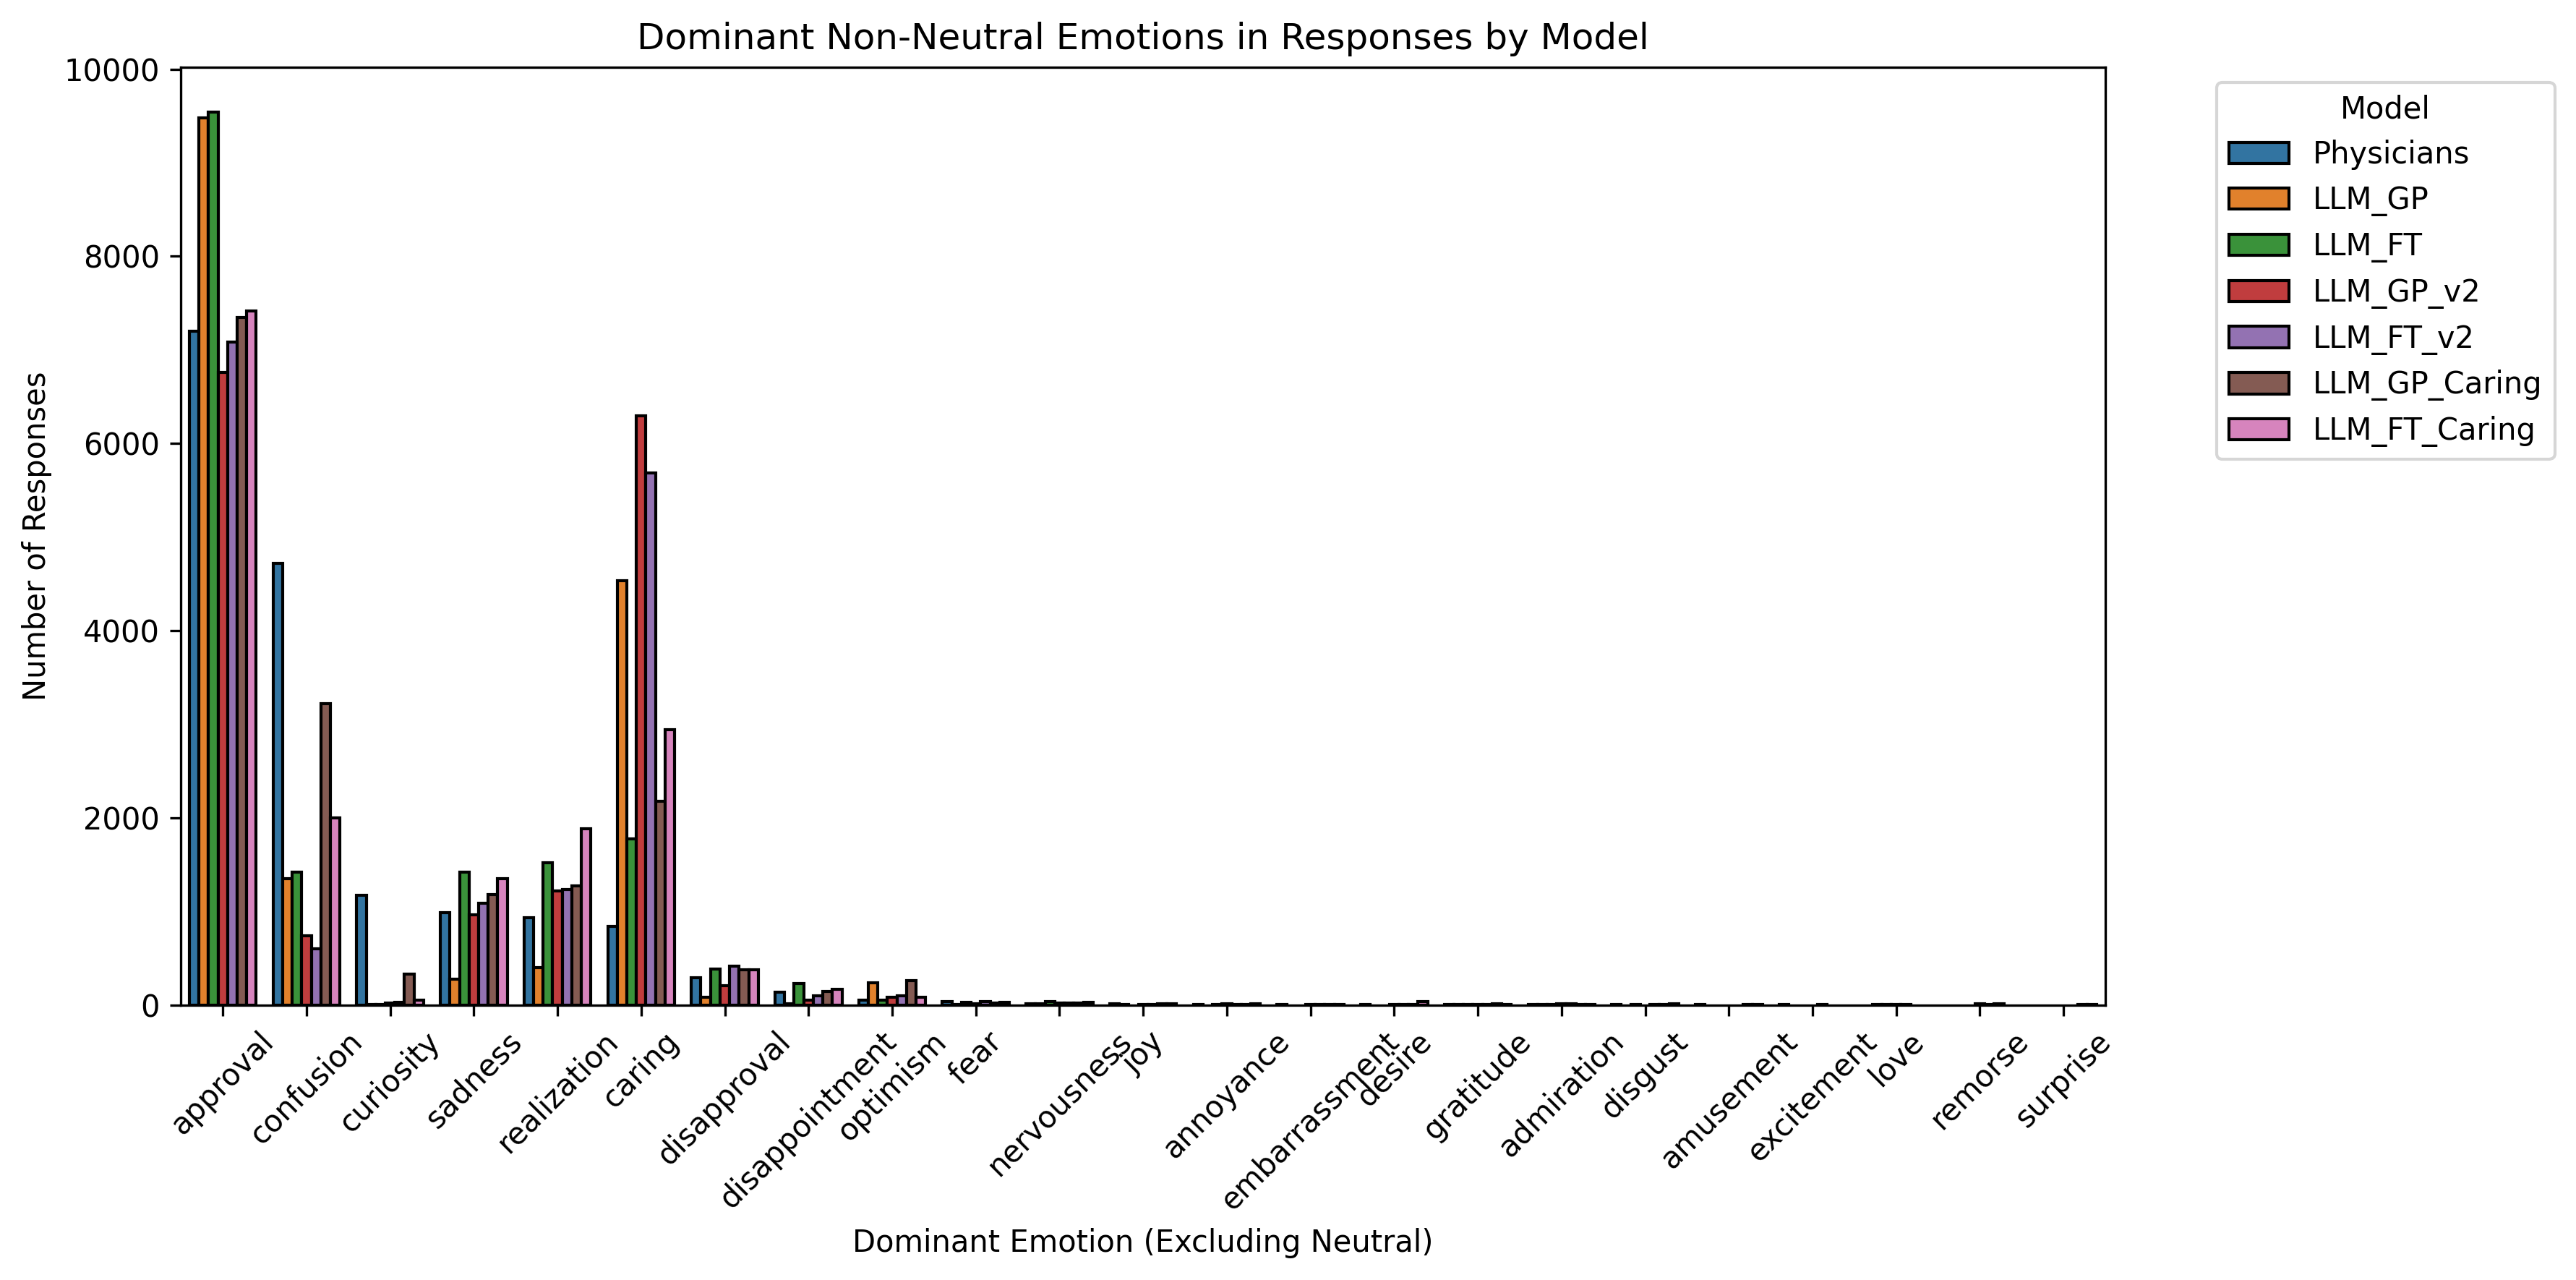


📊 Chi-Squared Test on Non-Neutral Dominant Emotion Distributions
Chi² statistic = 23141.69
Degrees of freedom = 132
p-value = 0.0000e+00
Significant difference among models?  ✅ Yes


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
from collections import Counter
from scipy.stats import chi2_contingency

# === MAPPATURA COLONNE A NOMI COERENTI ===
emotion_cols = {
    "Answer_medico_emotions": "Physicians",
    "Answer_LLM_emotions": "LLM_GP",
    "Answer_LLM_PALMYRA_emotions": "LLM_FT",
    "Answer_LLM_prompt2_emotions": "LLM_GP_v2",
    "Answer_LLM_PALMYRA_prompt2_emotions": "LLM_FT_v2",
    "Answer_medico_caring_LLM_emotions": "LLM_GP_Caring",
    "Answer_medico_caring_LLM_PALMYRA_emotions": "LLM_FT_Caring"
}

# === FUNZIONE PER ESTRARRE L’EMOZIONE DOMINANTE (escludendo 'neutral') ===
def extract_dominant_emotion(x):
    try:
        cleaned = re.sub(r'np\.float64\((.*?)\)', r'\1', str(x))
        d = ast.literal_eval(cleaned)
        if isinstance(d, dict) and d:
            d = {k: v for k, v in d.items() if k.lower() != 'neutral'}
            if d:
                return max(d.items(), key=lambda item: item[1])[0]
    except Exception:
        pass
    return None

# === ESTRAZIONE DOMINANTI ===
dominant_emotions = []

for col, label in emotion_cols.items():
    dominant = df[col].dropna().apply(extract_dominant_emotion)
    counts = dominant.value_counts()
    for emotion, freq in counts.items():
        dominant_emotions.append({
            "Model": label,
            "Emotion": emotion,
            "Frequency": freq
        })

# === COSTRUZIONE DATAFRAME ===
dominant_df = pd.DataFrame(dominant_emotions)

# Rimuovi eventuali 'neutral' residui per sicurezza
dominant_df = dominant_df[dominant_df["Emotion"].str.lower() != "neutral"]

# === PLOT ===
plt.figure(figsize=(12, 6), dpi=300)
sns.barplot(data=dominant_df, x="Emotion", y="Frequency", hue="Model", edgecolor='black')
plt.title("Dominant Non-Neutral Emotions in Responses by Model")
plt.xlabel("Dominant Emotion (Excluding Neutral)")
plt.ylabel("Number of Responses")
plt.xticks(rotation=45)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("dominant_non_neutral_emotions_by_model_gp_ft.pdf", format="pdf", dpi=300)
plt.show()

# === TEST CHI-QUADRATO ===
pivot = dominant_df.pivot_table(index="Model", columns="Emotion", values="Frequency", fill_value=0)
chi2, p, dof, expected = chi2_contingency(pivot)

print("\n📊 Chi-Squared Test on Non-Neutral Dominant Emotion Distributions")
print(f"Chi² statistic = {chi2:.2f}")
print(f"Degrees of freedom = {dof}")
print(f"p-value = {p:.4e}")
print("Significant difference among models? ", "✅ Yes" if p < 0.05 else "❌ No")


In [9]:
# -------------------------------
# 🔝 Top 5 emotions per model (%)
# -------------------------------
print("\n📊 Top 5 dominant emotions (percentage per model):")

# Calcolo del totale risposte per ciascun modello
totals_per_model = dominant_df.groupby("Model")["Frequency"].sum().to_dict()

# Calcolo delle percentuali
top5_summary = []

for model in emotion_cols.values():
    # Filtra le emozioni per modello
    subset = dominant_df[dominant_df["Model"] == model].copy()
    subset["Percent"] = (subset["Frequency"] / totals_per_model[model]) * 100
    # Ordina e prendi le prime 5
    top5 = subset.sort_values(by="Frequency", ascending=False).head(5)
    for _, row in top5.iterrows():
        top5_summary.append({
            "Model": model,
            "Emotion": row["Emotion"],
            "Frequency": int(row["Frequency"]),
            "Percent": f"{row['Percent']:.1f}%"
        })

# Stampa come tabella
top5_df = pd.DataFrame(top5_summary)
print(top5_df)

# (opzionale) salva in CSV
top5_df.to_csv("top5_dominant_emotions_by_model.csv", index=False)



📊 Top 5 dominant emotions (percentage per model):
            Model      Emotion  Frequency Percent
0      Physicians     approval       7201   43.9%
1      Physicians    confusion       4719   28.8%
2      Physicians    curiosity       1169    7.1%
3      Physicians      sadness        984    6.0%
4      Physicians  realization        933    5.7%
5          LLM_GP     approval       9479   57.8%
6          LLM_GP       caring       4533   27.6%
7          LLM_GP    confusion       1351    8.2%
8          LLM_GP  realization        401    2.4%
9          LLM_GP      sadness        274    1.7%
10         LLM_FT     approval       9543   58.2%
11         LLM_FT       caring       1774   10.8%
12         LLM_FT  realization       1518    9.3%
13         LLM_FT    confusion       1421    8.7%
14         LLM_FT      sadness       1418    8.6%
15      LLM_GP_v2     approval       6762   41.2%
16      LLM_GP_v2       caring       6298   38.4%
17      LLM_GP_v2  realization       1220    7.4%

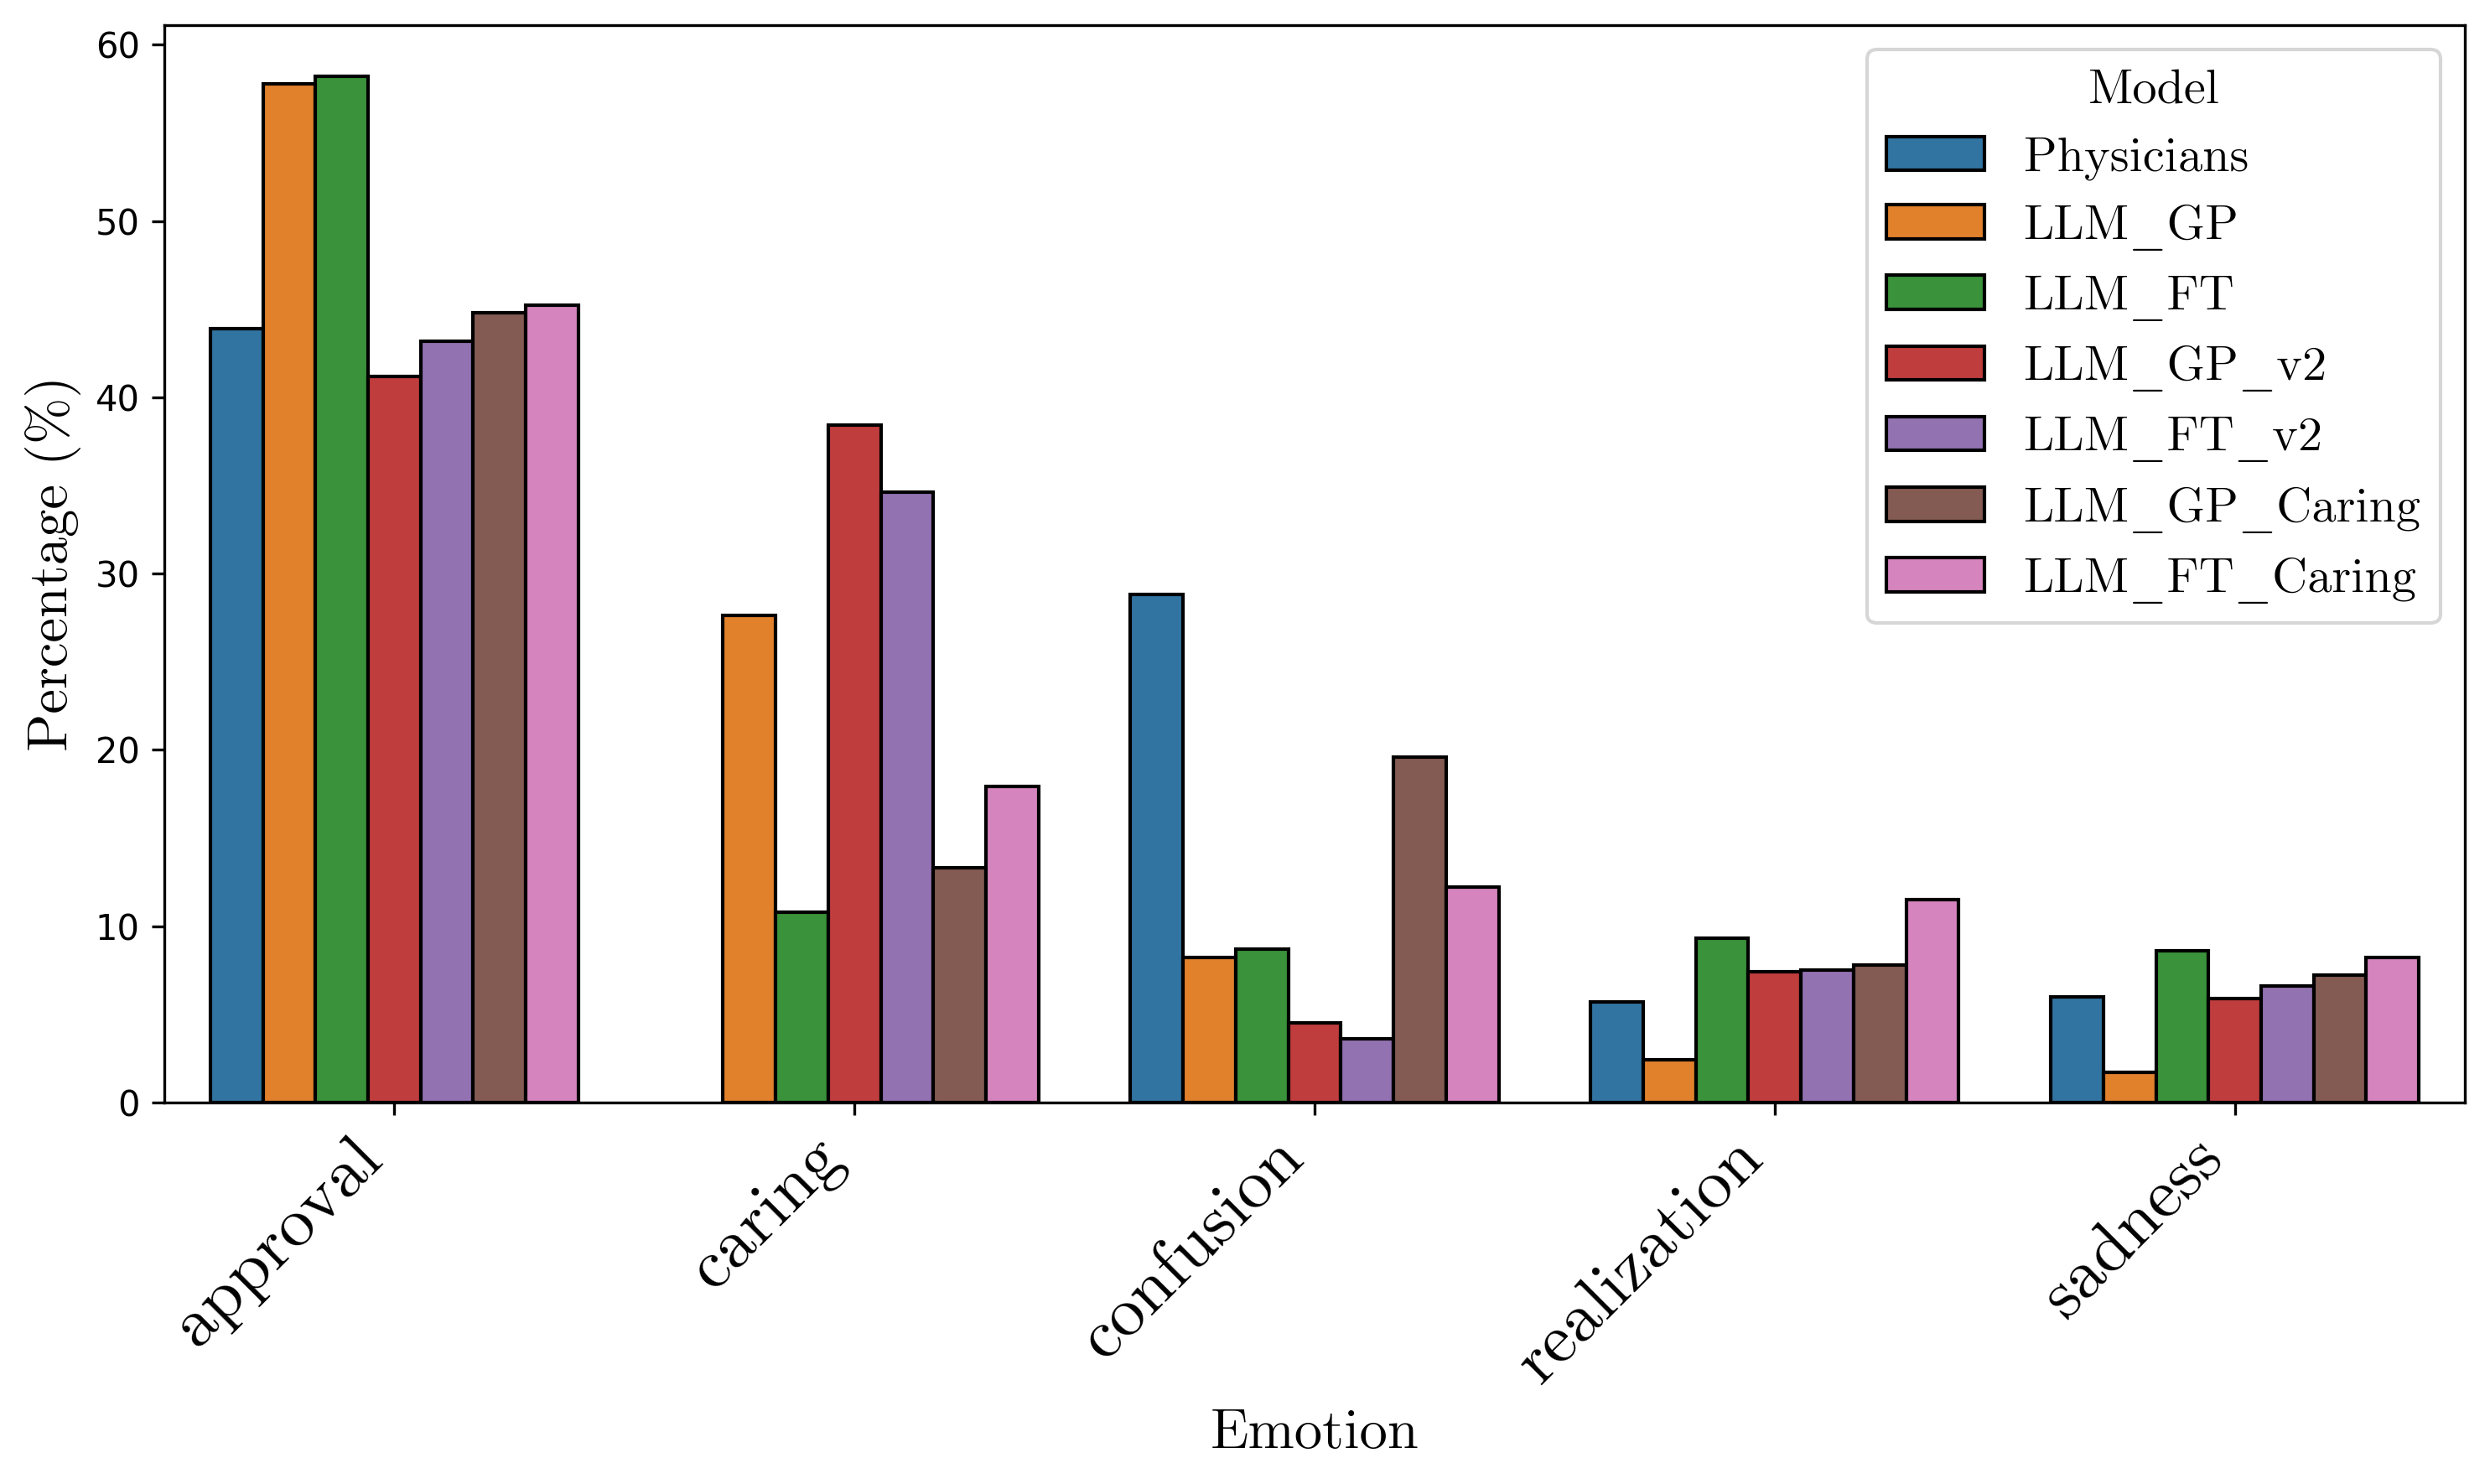

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import font_manager as fm

# === Disabilita il simbolo unicode minus ===
mpl.rcParams['axes.unicode_minus'] = False

# === Carica il font Computer Modern ===
font_path = "/content/fonts/cmunrm.ttf"  # Assicurati che il percorso sia corretto
cmu_font = fm.FontProperties(fname=font_path)
fallback_font = fm.FontProperties(family="DejaVu Sans")

# === Imposta dimensioni dei font personalizzati ===
title_fontsize = 22
xlabel_fontsize = 16
ylabel_fontsize = 16
xtick_fontsize = 20
ytick_fontsize = 20
legend_fontsize = 14

cmu_font_title = cmu_font.copy(); cmu_font_title.set_size(title_fontsize)
cmu_font_xlabel = cmu_font.copy(); cmu_font_xlabel.set_size(xlabel_fontsize)
cmu_font_ylabel = cmu_font.copy(); cmu_font_ylabel.set_size(ylabel_fontsize)
cmu_font_xtick = cmu_font.copy(); cmu_font_xtick.set_size(xtick_fontsize)
cmu_font_legend = cmu_font.copy(); cmu_font_legend.set_size(legend_fontsize)

# === Assicura che Percent sia float (senza % simbolo), solo se serve ===
if top5_df["Percent"].dtype == "object":
    top5_df["Percent"] = top5_df["Percent"].str.replace("%", "").astype(float)

# === Calcola la somma percentuale per ogni emozione e prendi le top 5 ===
emotion_order = (
    top5_df.groupby("Emotion")["Percent"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# === Filtra il dataframe per includere solo le top 5 emozioni ===
top5_df_filtered = top5_df[top5_df["Emotion"].isin(emotion_order)]

# === Crea il barplot ===
plt.figure(figsize=(10, 6), dpi=300)
sns.barplot(
    data=top5_df_filtered,
    x="Emotion",
    y="Percent",
    hue="Model",
    order=emotion_order,
    edgecolor="black"
)

plt.title("", fontproperties=cmu_font_title)
plt.ylabel("Percentage (%)", fontproperties=cmu_font_ylabel)
plt.xlabel("Emotion", fontproperties=cmu_font_xlabel)
plt.xticks(rotation=45, ha='right', fontproperties=cmu_font_xtick)
plt.yticks(fontsize=ytick_fontsize, fontproperties=fallback_font)
plt.legend(title="Model", prop=cmu_font_legend, title_fontproperties=cmu_font_legend)

plt.tight_layout()
plt.savefig("top5_dominant_emotions_by_model.pdf", format="pdf", dpi=300)
plt.show()
